<h1>Capítulo 6 - Engenharia de Prompt</h1>
<i>Métodos para melhorar a saída de LLMs por meio da engenharia de prompt.</i>

---

Este notebook é baseado no Capítulo 6 do livro [Hands-On Large Language Models](https://www.amazon.com/Hands-Large-Language-Models-Understanding/dp/1098150961), de [Jay Alammar](https://www.linkedin.com/in/jalammar) e [Maarten Grootendorst](https://www.linkedin.com/in/mgrootendorst/).

**Disciplina:** Tópicos Especiais em Inteligência Artificial (IFPE, Campus Paulista). **Aula:** Engenharia de Prompt.

---

## Sobre esta versão do notebook

Nos slides vimos **o que** cada técnica de engenharia de prompt faz. Neste notebook vamos **medir** o efeito de cada uma. Para isso, cada seção do livro ganhou um bloco **Comparação**, no qual a mesma tarefa é executada **sem** e **com** a técnica, e o resultado é resumido em uma tabela com métricas simples (formato correto, acurácia, número de tokens, tempo).

| Slide da aula | Seção do notebook | Comparação |
|---|---|---|
| Prompt: o que o modelo realmente recebe | Primeira geração | 1. Com e sem *chat template* |
| Temperatura, top_p, top_k | Controlando a saída | 2. Distribuição do próximo token; 3. Diversidade das respostas |
| Ingredientes básicos, instrução + dados, indicadores de saída | Ingredientes de um prompt | 4. Apenas dados vs. instrução vs. indicadores |
| Técnicas que valem para qualquer tarefa | Prompting baseado em instruções | 5. Especificidade; 6. Alucinação; 7. Ordem (primazia e recência) |
| Componentes e construção iterativa | Prompt complexo | 8. Ablação dos componentes |
| Zero-shot, one-shot, few-shot | Aprendizado em contexto | 9. Zero, one e few-shot; 10. Triagem de mensagens |
| Encadeamento de prompts | Encadeamento | 11. Prompt único vs. cadeia com validação |
| Chain-of-Thought | Raciocínio | 12. Resposta direta vs. CoT |
| Autoconsistência | Raciocínio | 13. Uma amostra vs. votação majoritária |
| Tree-of-Thought | Raciocínio | 14. CoT vs. ToT em um único prompt |
| Verificação da saída | Verificação | 15. JSON zero-shot vs. one-shot; 16. Gramática (amostragem restrita) |
| (extra) | Bônus | Repetindo comparações com a API gratuita do Gemini |

### Como ler os resultados

As amostras são pequenas (de 5 a 12 itens por experimento) para caber no tempo de aula. Trate os números como **tendências observadas neste modelo, neste idioma e neste hardware**, e não como conclusões gerais. Resultados podem mudar ao trocar o modelo (Phi-3 na GPU, Qwen na CPU), ao reescrever um prompt ou até ao atualizar a biblioteca `transformers`. Justamente por isso a engenharia de prompt é um processo **experimental e iterativo** (ALAMMAR; GROOTENDORST, 2024, p. 173).

In [48]:
# Instalando uma tradutor
!pip install deep-translator
from deep_translator import GoogleTranslator
tradutor = GoogleTranslator(source='en', target='pt')


### Escolha do ambiente: Colab (GPU T4) ou EC2 (somente CPU)

| Ambiente | Modelo com `transformers` | Modelo com `llama.cpp` (seção de gramática) | Recomendação |
|---|---|---|---|
| Google Colab, GPU T4 (gratuito) | `microsoft/Phi-3-mini-4k-instruct` (3,8 bilhões de parâmetros; cerca de 7,6 GB em fp16) | `microsoft/Phi-3-mini-4k-instruct-gguf` (fp16) | Execute as células originais normalmente, com `MODO_RAPIDO = False`. |
| AWS EC2 sem GPU | `Qwen/Qwen2.5-0.5B-Instruct` (cerca de 2 GB em fp32); use `Qwen/Qwen2.5-1.5B-Instruct` se a instância tiver 8 GB de RAM ou mais | `Qwen/Qwen2.5-0.5B-Instruct-GGUF` (quantizado q4_k_m) | Pule as células que carregam o Phi-3, execute as células alternativas marcadas com **EC2** e use `MODO_RAPIDO = True`. |

Um detalhe didático importante: **as técnicas de prompt costumam fazer mais diferença em modelos menores**. Se você tiver tempo, rode as comparações com os dois modelos e compare as tabelas.

## Carregando o modelo

A célula abaixo carrega o Phi-3-mini (ABDIN et al., 2024) e cria um `pipeline` de geração de texto. Os parâmetros mais importantes:

* `device_map="cuda"`: coloca o modelo na GPU. **Falha em máquinas sem GPU** (use a alternativa para EC2 logo abaixo).
* `torch_dtype="auto"`: usa a precisão definida pelo autor do modelo (aqui, meia precisão), reduzindo a memória pela metade em relação a fp32.
* `return_full_text=False`: devolve apenas o texto gerado, sem repetir o prompt.
* `max_new_tokens=500`: limite de tokens gerados por chamada.
* `do_sample=False`: **decodificação gulosa** (sempre o token mais provável). É o que os slides chamam de "temperatura 0". No `transformers`, a temperatura precisa ser estritamente positiva quando `do_sample=True`; por isso "temperatura 0" é implementada como `do_sample=False`.

Referência: ALAMMAR; GROOTENDORST (2024, p. 168-170).

In [49]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

# Load model and tokenizer
model = AutoModelForCausalLM.from_pretrained(
    "microsoft/Phi-3-mini-4k-instruct",
    device_map="cuda",
    torch_dtype="auto",
    trust_remote_code=False,
)
tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-4k-instruct")

# Create a pipeline
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    return_full_text=False,
    max_new_tokens=500,
    do_sample=False,
)

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

### Alternativa para EC2 (somente CPU)

Em uma instância sem GPU, **não execute a célula anterior**. Mude `USAR_CPU` para `True` e execute a célula abaixo. Ela cria as mesmas variáveis (`model`, `tokenizer`, `pipe`), de modo que todas as células seguintes funcionam sem alteração.

O Qwen2.5 (QWEN TEAM, 2024) usa um *chat template* diferente do Phi-3, o que é ótimo para comparar na próxima seção.

In [50]:
USAR_CPU = False  # mude para True em uma instância EC2 sem GPU

if USAR_CPU:
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

    MODELO_CPU = "Qwen/Qwen2.5-0.5B-Instruct"  # ou "Qwen/Qwen2.5-1.5B-Instruct" com 8 GB de RAM ou mais

    model = AutoModelForCausalLM.from_pretrained(MODELO_CPU, device_map="cpu", torch_dtype=torch.float32)
    tokenizer = AutoTokenizer.from_pretrained(MODELO_CPU)
    pipe = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        return_full_text=False,
        max_new_tokens=500,
        do_sample=False,
    )
    print(f"Modelo {MODELO_CPU} carregado na CPU.")

### Utilitários para as comparações

A célula abaixo define funções usadas em todo o notebook. Ela **não** gera texto; apenas prepara as ferramentas de medição:

* `gerar(entrada, **parametros)`: chama o `pipe` e devolve um dicionário com o texto, o número de tokens gerados e o tempo gasto.
* `gerar_varias(entrada, n, **parametros)`: gera `n` respostas amostradas em uma única chamada (usada na autoconsistência).
* Funções de avaliação: extraem rótulos, números e objetos JSON das respostas e calculam as métricas.

Todas as funções de avaliação aceitam o argumento `gerador`. Por padrão ele é o modelo local; na seção bônus, trocamos pelo Gemini sem mudar mais nada.

Defina `MODO_RAPIDO = True` em CPU: os experimentos passam a usar apenas os primeiros itens de cada conjunto.

In [51]:
import re
import time
import json
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import set_seed
from transformers.utils import logging as hf_logging

hf_logging.set_verbosity_error()  # oculta avisos repetitivos do pipeline
pd.set_option("display.max_colwidth", 120)

# True reduz o número de itens de cada experimento (recomendado em CPU)
MODO_RAPIDO = False


# ------------------------------------------------------------------ geração
def usuario(texto):
    """Empacota um texto como uma única fala do usuário (formato de chat)."""
    return [{"role": "user", "content": texto}]


def contar_tokens(texto):
    return len(tokenizer(texto, add_special_tokens=False)["input_ids"])


def gerar(entrada, **parametros):
    """Gera uma resposta e devolve texto, tokens gerados e tempo em segundos.

    entrada: lista de mensagens (o pipeline aplica o chat template)
             ou string (texto cru, enviado sem template).
    parametros: repassados ao pipeline (max_new_tokens, do_sample, temperature, ...).
    """
    inicio = time.perf_counter()
    saida = pipe(entrada, **parametros)[0]["generated_text"]
    duracao = time.perf_counter() - inicio
    return {"texto": saida.strip(), "tokens": contar_tokens(saida), "segundos": round(duracao, 2)}


def gerar_varias(entrada, n, **parametros):
    """Gera n respostas amostradas para a mesma entrada, em uma única chamada."""
    inicio = time.perf_counter()
    saidas = pipe(entrada, num_return_sequences=n, **parametros)
    duracao = time.perf_counter() - inicio
    textos = [s["generated_text"].strip() for s in saidas]
    return {"textos": textos, "tokens": sum(contar_tokens(t) for t in textos), "segundos": round(duracao, 2)}


def mostrar(titulo, resultado, limite=1200):
    """Imprime uma resposta com cabeçalho, tokens e tempo."""
    texto = resultado["texto"]
    if len(texto) > limite:
        texto = texto[:limite] + " [...]"
    print(f"===== {titulo} | {resultado['tokens']} tokens | {resultado['segundos']} s =====")
    print(texto, end="\n\n")


def amostra(lista, n_rapido):
    """Em MODO_RAPIDO, usa apenas os n_rapido primeiros itens da lista."""
    return lista[:n_rapido] if MODO_RAPIDO else lista


def sem_acentos(texto):
    return "".join(c for c in unicodedata.normalize("NFD", texto) if unicodedata.category(c) != "Mn")


# ------------------------------------------------------------ classificação
def extrair_rotulo(resposta):
    """Extração tolerante: primeiro rótulo de sentimento mencionado (aceita português e inglês)."""
    achados = re.findall(r"positiv|negativ|neutr", resposta.lower())
    mapa = {"positiv": "positivo", "negativ": "negativo", "neutr": "neutro"}
    return mapa[achados[0]] if achados else None


def formato_estrito(resposta):
    """True se a resposta inteira for exatamente um rótulo (pontuação ao redor é tolerada)."""
    return re.fullmatch(r"\W*(positivo|negativo|neutro)\W*", resposta.strip().lower()) is not None


def avaliar_classificacao(nome, construir_prompt, dados, gerador=None, **parametros):
    """Executa um classificador de sentimento baseado em prompt e resume as métricas."""
    gerador = gerador or gerar
    parametros = {"max_new_tokens": 60, **parametros}
    linhas = []
    for texto, esperado in dados:
        r = gerador(construir_prompt(texto), **parametros)
        previsto = extrair_rotulo(r["texto"])
        linhas.append({"texto": texto, "esperado": esperado, "previsto": previsto,
                       "formato_ok": formato_estrito(r["texto"]), "acerto": previsto == esperado,
                       "tokens": r["tokens"], "segundos": r["segundos"], "resposta": r["texto"]})
    detalhe = pd.DataFrame(linhas)
    resumo = {"configuração": nome,
              "formato estrito (%)": round(100 * detalhe["formato_ok"].mean(), 1),
              "acurácia (%)": round(100 * detalhe["acerto"].mean(), 1),
              "tokens médios": round(detalhe["tokens"].mean(), 1),
              "tempo total (s)": round(detalhe["segundos"].sum(), 1)}
    return resumo, detalhe


# --------------------------------------------------------------- raciocínio (reasoning)
def extrair_numero(texto):
    """Procura 'Resposta: <número>'; se não houver, usa o último número do texto."""
    m = re.search(r"resposta\s*[:=]\s*(?:R\$\s*)?(-?\d+(?:[.,]\d+)?)", texto, flags=re.IGNORECASE)
    if m:
        bruto = m.group(1)
    else:
        numeros = re.findall(r"-?\d+(?:[.,]\d+)?", texto)
        if not numeros:
            return None
        bruto = numeros[-1]
    return float(bruto.replace(",", "."))


def acertou(valor, esperado):
    return valor is not None and abs(valor - esperado) < 1e-6


def avaliar_raciocinio(nome, construir_prompt, problemas, gerador=None, **parametros):
    """Resolve uma lista de (enunciado, resposta) e resume acurácia e custo."""
    gerador = gerador or gerar
    linhas = []
    for enunciado, esperado in problemas:
        r = gerador(construir_prompt(enunciado), **parametros)
        valor = extrair_numero(r["texto"])
        linhas.append({"enunciado": enunciado[:60] + "...", "esperado": esperado, "extraído": valor,
                       "acerto": acertou(valor, esperado), "tokens": r["tokens"],
                       "segundos": r["segundos"], "resposta": r["texto"]})
    detalhe = pd.DataFrame(linhas)
    resumo = {"configuração": nome,
              "acurácia (%)": round(100 * detalhe["acerto"].mean(), 1),
              "tokens médios": round(detalhe["tokens"].mean(), 1),
              "tempo total (s)": round(detalhe["segundos"].sum(), 1)}
    return resumo, detalhe


# --------------------------------------------------------------------- JSON
ESQUEMA_CHAVES = {"description", "name", "armor", "weapon"}


def extrair_json(texto):
    """Remove cercas de código (```json) e tenta ler o trecho entre a primeira { e a última }."""
    limpo = re.sub(r"```(?:json)?", "", texto).strip()
    inicio, fim = limpo.find("{"), limpo.rfind("}")
    if inicio == -1 or fim == -1:
        return None
    try:
        return json.loads(limpo[inicio:fim + 1])
    except json.JSONDecodeError:
        return None


def avaliar_json(texto):
    """Três níveis de exigência: JSON puro, JSON após limpeza e aderência ao esquema."""
    try:
        objeto = json.loads(texto)
        direto = True
    except json.JSONDecodeError:
        objeto = extrair_json(texto)
        direto = False
    conforme = (isinstance(objeto, dict) and set(objeto) == ESQUEMA_CHAVES
                and all(isinstance(v, str) for v in objeto.values()))
    return {"json.loads direto": direto, "JSON após limpeza": objeto is not None, "segue o esquema": conforme}


def resumir_json(nome, textos, tokens_medios=None):
    avaliacoes = pd.DataFrame([avaliar_json(t) for t in textos])
    resumo = {"configuração": nome, **{c: round(100 * avaliacoes[c].mean(), 1) for c in avaliacoes.columns}}
    if tokens_medios is not None:
        resumo["tokens médios"] = round(tokens_medios, 1)
    return resumo


print("Utilitários prontos. MODO_RAPIDO =", MODO_RAPIDO)

Utilitários prontos. MODO_RAPIDO = False


## Gerando a primeira resposta

Em modelos de chat, o prompt é uma **lista de mensagens**, cada uma com um papel (`role`): `system` (instruções gerais, quando o modelo suporta), `user` (o usuário) e `assistant` (o modelo). O pipeline converte essa lista em texto usando o *chat template* do modelo (ALAMMAR; GROOTENDORST, 2024, p. 169-170).

In [52]:
# Prompt
messages = [
    {"role": "user", "content": "Create a funny joke about chickens."}
]

# Generate the output
output = pipe(messages)
print(output[0]["generated_text"])
#print(tradutor.translate(output[0]["generated_text"]))

Why did the chicken join the band? Because it had the drumsticks!


Aplicando o *prompt template*

In [53]:
# Apply prompt template
prompt = pipe.tokenizer.apply_chat_template(messages, tokenize=False)
print(prompt)

<|user|>
Create a funny joke about chickens.<|end|>
<|endoftext|>


Repare nos tokens especiais: `<|user|>` marca o início da fala do usuário, `<|end|>` marca o fim de cada fala e `<|assistant|>` sinaliza que agora é a vez do modelo. É exatamente o que o slide "Prompt: o que o modelo realmente recebe" mostra.

Observação técnica: o template do Phi-3 já acrescenta `<|assistant|>` mesmo sem pedir. Em outros modelos (como o Qwen), isso só acontece com `add_generation_prompt=True`. Se estiver usando o Qwen, execute a célula anterior e compare: ele também insere uma mensagem de sistema padrão.

### Comparação 1: com e sem *chat template*

**O que esperar.** Se enviarmos uma **string** ao pipeline, ela vai crua, sem tokens especiais. O modelo não sabe que existe uma "fala do usuário" e se comporta como um modelo base: apenas **continua o texto** (slide "Os ingredientes básicos de um prompt"). Com a **lista de mensagens**, o template é aplicado e o modelo responde como assistente.

In [54]:
entradas = ["O céu é", "Traduza para o inglês: Bom dia, turma."]

for entrada in entradas:
    sem_template = gerar(entrada, max_new_tokens=40)            # string: vai crua, sem tokens especiais
    com_template = gerar(usuario(entrada), max_new_tokens=40)   # lista de mensagens: pipeline aplica o template
    print("-" * 80)
    print("ENTRADA:", entrada, "\n")
    mostrar("SEM template (continuação de texto)", sem_template)
    mostrar("COM template (resposta de assistente)", com_template)

print("O que o modelo recebeu no caso COM template:")
print(tokenizer.apply_chat_template(usuario(entradas[-1]), tokenize=False, add_generation_prompt=True))

--------------------------------------------------------------------------------
ENTRADA: O céu é 

===== SEM template (continuação de texto) | 40 tokens | 2.0 s =====
azul.


### Response:
O céu é azul.


### Instruction:

Como a literatura de autoria de Gabriel García

===== COM template (resposta de assistente) | 40 tokens | 2.02 s =====
O céu é um vasto espaço que se estende acima da superfície da Terra. Geralmente é descrito como azul devido à dispersão da l

--------------------------------------------------------------------------------
ENTRADA: Traduza para o inglês: Bom dia, turma. 

===== SEM template (continuação de texto) | 41 tokens | 2.02 s =====
**Tradução para o inglês:** Good morning, class.


**Instrucción en español de mayor dificultad:**

Traduce al

===== COM template (resposta de assistente) | 5 tokens | 0.43 s =====
Good morning, class.

O que o modelo recebeu no caso COM template:
<|user|>
Traduza para o inglês: Bom dia, turma.<|end|>
<|assistant|>



**Como interpretar.** Sem template, é comum o modelo continuar a frase, repetir o padrão da entrada, inventar novas perguntas ou não parar onde esperamos. Com template, a resposta tem começo e fim bem definidos. Interfaces como Gemini e ChatGPT fazem essa formatação por você; ao usar modelos abertos ou APIs, **é responsabilidade do programador**.

**Pergunta para discussão.** Um agente que envia a saída de uma ferramenta de volta ao modelo como texto solto, sem o papel correto, pode confundir o modelo. Por quê?

## Controlando a saída do modelo

A cada passo, o modelo produz um **logit** $z_i$ para cada token $i$ do vocabulário. A temperatura $T$ entra antes da *softmax*:

$$p_i = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

* $T < 1$ concentra a probabilidade nos tokens mais prováveis; $T \to 0$ equivale à decodificação gulosa.
* $T > 1$ achata a distribuição, dando mais chance a tokens improváveis.
* **top_p** (amostragem por núcleo; HOLTZMAN et al., 2020) sorteia apenas dentro do menor conjunto de tokens cuja probabilidade acumulada atinge $p$.
* **top_k** sorteia apenas entre os $k$ tokens mais prováveis. Atenção: no `transformers`, o valor padrão costuma ser `top_k=50`; para desligá-lo, use `top_k=0`.

Referência: ALAMMAR; GROOTENDORST (2024, p. 170-172); documentação *Generation strategies* do Hugging Face.

As duas células originais abaixo geram piadas com temperatura alta e com top_p alto:

Na célula anterior, o pipeline usou **decodificação gulosa** (`do_sample=False`, definido na criação do `pipe`): a cada passo, o modelo escolhe sempre o token mais provável. Por isso, a mesma pergunta gera sempre a mesma piada.

Aqui mudamos dois parâmetros apenas para esta chamada, sem alterar o `pipe`:

* `do_sample=True`: liga a **amostragem**. Em vez de pegar sempre o primeiro colocado, o próximo token é **sorteado** de acordo com as probabilidades calculadas pelo modelo. Sem esse parâmetro, a temperatura é ignorada.
* `temperature=1`: usa a distribuição de probabilidades **original** do modelo, sem concentrá-la nem achatá-la. É "alta" quando comparada à decodificação gulosa (equivalente a temperatura 0): tokens menos prováveis, como o "elefante" do exemplo dos slides, passam a ter chance real de serem escolhidos. Valores menores que 1 concentram a probabilidade nos tokens mais prováveis; valores maiores que 1 achatam a distribuição e deixam o texto mais imprevisível (e, no extremo, sem sentido).

Execute a célula várias vezes: a piada deve mudar a cada execução, ao contrário da versão gulosa. Essa variação é útil em tarefas criativas (como gerar piadas ou nomes de produtos), mas é indesejada quando a saída será lida por um programa, como em agentes.


In [55]:
# Using a high temperature
output = pipe(messages, do_sample=True, temperature=1)
print(output[0]["generated_text"])
#print(tradutor.translate(output[0]["generated_text"]))

Why don't chickens play piano? Because they're afraid they'd be a clucktivist!


Enquanto a temperatura **altera** as probabilidades, o **top_p** (amostragem por núcleo) **limita quais tokens podem ser sorteados**. O procedimento a cada passo é:

1. Ordenar os tokens do mais provável para o menos provável.
2. Somar as probabilidades, nessa ordem, até atingir o valor `p`.
3. Sortear o próximo token apenas dentro desse conjunto, chamado de **núcleo**.

Nesta célula:

* `do_sample=True`: liga a amostragem, como na célula anterior. Sem ele, o top_p é ignorado e a decodificação continua gulosa.
* `top_p=1`: é o valor máximo. Com ele, o núcleo inclui **todos** os tokens do vocabulário, ou seja, o top_p **não restringe nada**. Com `top_p=0.1`, por outro lado, só entrariam os poucos tokens mais prováveis cuja soma chega a 10%, e a saída ficaria quase igual à da decodificação gulosa.


In [56]:
# Using a high top_p
output = pipe(messages, do_sample=True, top_p=1)
print(output[0]["generated_text"])
#print(tradutor.translate(output[0]["generated_text"]))

Why don't chickens play musical instruments? Because they can't find the time between pecking their eggs and laying their tunes!


### Comparação 2: temperatura, top_p e top_k na distribuição do próximo token

**O que esperar.** Vamos abrir a "caixa-preta" e olhar a distribuição real do próximo token para a frase do slide, "Eu estou dirigindo um". Com temperatura baixa, quase toda a probabilidade fica no primeiro token; com temperatura alta, a distribuição se achata. O tamanho do núcleo do top_p deve crescer rapidamente conforme $p$ aumenta.

Lembre-se do Capítulo 2: o modelo prevê **tokens**, não palavras. "carro" pode aparecer como um pedaço (por exemplo, `' car'`), e por isso usamos `repr` para mostrar os espaços.

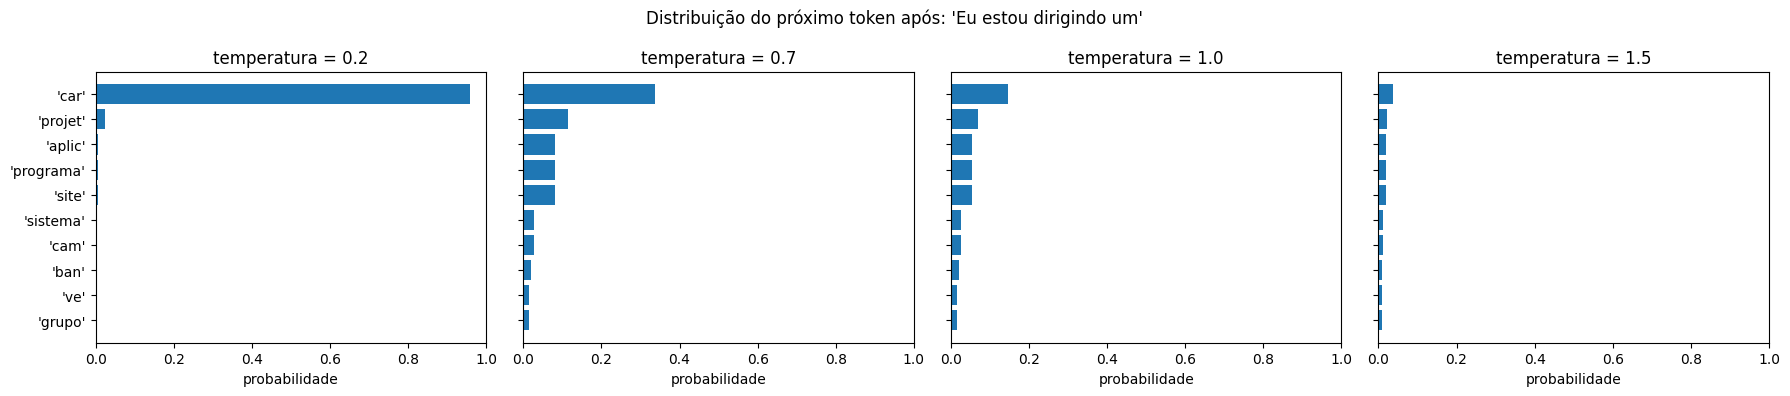

,temperatura,prob. do 1º token,entropia (bits)
0,0.2,0.958,0.33
1,0.7,0.337,4.21
2,1.0,0.145,6.99
3,1.5,0.036,10.26


,top_p,tokens no núcleo
0,0.10,1
1,0.50,12
2,0.90,317
3,0.95,672
4,0.99,2209


,top_k,probabilidade coberta
0,1,0.145
1,5,0.374
2,50,0.699


Tamanho do vocabulário: 32064 tokens


In [57]:
import torch

frase = "Eu estou dirigindo um"
entrada_ids = tokenizer(frase, return_tensors="pt").to(model.device)
with torch.no_grad():
    logits = model(**entrada_ids).logits[0, -1, :].float().cpu().numpy()


def softmax_com_temperatura(logits, temperatura):
    z = logits / temperatura
    z = z - z.max()  # estabilidade numérica
    p = np.exp(z)
    return p / p.sum()


K_MOSTRAR = 10
ordem = np.argsort(-logits)[:K_MOSTRAR]
rotulos = [repr(tokenizer.decode([int(i)])) for i in ordem]

temperaturas = [0.2, 0.7, 1.0, 1.5]
fig, eixos = plt.subplots(1, len(temperaturas), figsize=(18, 4), sharey=True)
for eixo, T in zip(eixos, temperaturas):
    p = softmax_com_temperatura(logits, T)
    eixo.barh(rotulos[::-1], p[ordem][::-1])
    eixo.set_title(f"temperatura = {T}")
    eixo.set_xlim(0, 1)
    eixo.set_xlabel("probabilidade")
fig.suptitle(f"Distribuição do próximo token após: '{frase}'")
plt.tight_layout()
plt.show()

# Resumo numérico por temperatura
linhas = []
for T in temperaturas:
    p = softmax_com_temperatura(logits, T)
    entropia = float(-(p[p > 0] * np.log2(p[p > 0])).sum())
    linhas.append({"temperatura": T, "prob. do 1º token": round(float(p.max()), 3),
                   "entropia (bits)": round(entropia, 2)})
display(pd.DataFrame(linhas))

# Tamanho do núcleo (top_p) e massa coberta pelo top_k, com temperatura 1
p1 = softmax_com_temperatura(logits, 1.0)
acumulada = np.cumsum(np.sort(p1)[::-1])
nucleo = []
for top_p in [0.1, 0.5, 0.9, 0.95, 0.99]:
    tamanho = int(min(np.searchsorted(acumulada, top_p) + 1, len(acumulada)))
    nucleo.append({"top_p": top_p, "tokens no núcleo": tamanho})
display(pd.DataFrame(nucleo))

cobertura = [{"top_k": k, "probabilidade coberta": round(float(acumulada[k - 1]), 3)} for k in [1, 5, 50]]
display(pd.DataFrame(cobertura))
print(f"Tamanho do vocabulário: {len(p1)} tokens")

**Como interpretar.** A entropia mede a "incerteza" da distribuição: ela cresce com a temperatura. Observe que o top_p é **adaptativo**: quando o modelo está confiante, o núcleo tem poucos tokens; quando está em dúvida, o núcleo cresce. O top_k é **fixo**: `top_k=50` sempre mantém 50 candidatos, estejam eles razoáveis ou não.

**Pergunta para discussão.** Troque a frase por "A capital de Pernambuco é" e rode de novo. O que acontece com o tamanho do núcleo para `top_p=0.9`? Por quê?

### Comparação 3: diversidade das respostas

**O que esperar.** Vamos gerar várias respostas para o mesmo prompt com diferentes configurações. A decodificação gulosa e `top_k=1` devem produzir **sempre a mesma resposta**. Temperaturas altas devem produzir respostas diferentes a cada execução (e, no extremo, respostas sem sentido). Um `top_p` muito baixo deve anular o efeito de uma temperatura alta.

In [58]:
prompt_diversidade = usuario("Sugira um nome criativo para uma cafeteria em Recife. Responda apenas com o nome.")
N_REPETICOES = 3 if MODO_RAPIDO else 5

configuracoes = {
    "gulosa (do_sample=False)": dict(do_sample=False),
    "T=0.2": dict(do_sample=True, temperature=0.2, top_p=1.0, top_k=0),
    "T=1.0": dict(do_sample=True, temperature=1.0, top_p=1.0, top_k=0),
    "T=1.5": dict(do_sample=True, temperature=1.5, top_p=1.0, top_k=0),
    "T=1.0 e top_p=0.1": dict(do_sample=True, temperature=1.0, top_p=0.1, top_k=0),
    "T=1.0 e top_k=1": dict(do_sample=True, temperature=1.0, top_p=1.0, top_k=1),
}

linhas, exemplos = [], {}
for nome, parametros in configuracoes.items():
    respostas = []
    for semente in range(N_REPETICOES):
        set_seed(semente)  # sementes fixas tornam o experimento reproduzível
        respostas.append(gerar(prompt_diversidade, max_new_tokens=20, **parametros)["texto"])
    exemplos[nome] = respostas
    linhas.append({"configuração": nome, "respostas distintas": len(set(respostas)),
                   "de": N_REPETICOES, "exemplo": respostas[-1]})

display(pd.DataFrame(linhas))
for nome, respostas in exemplos.items():
    print(f"\n{nome}:")
    for r in respostas:
        print("  -", r.replace("\n", " "))

,configuração,respostas distintas,de,exemplo
0,gulosa (do_sample=False),1,5,Café da Mariposa Recife
1,T=0.2,5,5,Café da Praia Azul
2,T=1.0,5,5,Casa da Lua Dourada
3,T=1.5,5,5,Casa UmNho\n\n\nHash Guer with ItemMan An option C with JuggStrun
4,T=1.0 e top_p=0.1,2,5,Café da Praia Azul
5,T=1.0 e top_k=1,2,5,Café da Mariposa



gulosa (do_sample=False):
  - Café da Mariposa Recife
  - Café da Mariposa Recife
  - Café da Mariposa Recife
  - Café da Mariposa Recife
  - Café da Mariposa Recife

T=0.2:
  - Café da Ilusão
  - Café da Maravilha Recifense
  - Café da Maravilha do Recife
  - "Café da Esquina da Vida"
  - Café da Praia Azul

T=1.0:
  - "Azulejos Café de Luz"
  - Café da Cidade Ocidental    Desconstrua o desaf
  - "Cafe No Latido de Xangô"
  - "Bicho-Preto-Com-Luz Café"
  - Casa da Lua Dourada

T=1.5:
  - Bastante Pedida
  - Blustone Café
  - "Cafe No Latigazo do LoreslubBUAUBVCEOARR
  - "Bicho Friu Cavernas"  (A razão para colocarlou
  - Casa UmNho   Hash Guer with ItemMan An option C with JuggStrun

T=1.0 e top_p=0.1:
  - Café da Praia Azul
  - Café da Mariposa
  - Café da Mariposa
  - Café da Mariposa
  - Café da Praia Azul

T=1.0 e top_k=1:
  - Café da Mariposa
  - Café da Mariposa Recife
  - Café da Mariposa Recife
  - Café da Mariposa
  - Café da Mariposa


**Como interpretar.** A tabela do slide "Exemplos de uso" (brainstorming com temperatura e top_p altos; e-mail com ambos baixos) é uma **heurística**. Aqui você tem uma forma empírica de escolher: gere várias amostras e verifique se a variação obtida é a desejada.

**Pergunta para discussão.** Em um agente, a saída do modelo costuma ser lida por código (por exemplo, o nome de uma ferramenta a chamar). Qual configuração você usaria nesse caso? E para gerar ideias de nomes de produto?

# **Introdução à Engenharia de Prompt**

Engenharia de prompt vai além de escrever bons prompts: ela também serve para **avaliar** a saída do modelo e criar **salvaguardas** (*guardrails*). É um processo iterativo e experimental (ALAMMAR; GROOTENDORST, 2024, p. 173). As comparações desta parte transformam cada recomendação dos slides em um experimento.

## Os ingredientes básicos de um prompt

Um LLM é uma máquina de previsão: sem instrução, ele apenas completa o texto (vimos isso na Comparação 1). Para resolver tarefas, estruturamos o prompt em (ALAMMAR; GROOTENDORST, 2024, p. 173-175):

* **instrução**: o que fazer;
* **dados**: sobre o que fazer;
* **indicadores de saída**: prefixos como `Texto:` e `Sentimento:`, que sinalizam o formato esperado da resposta.


### Comparação 4: apenas dados vs. instrução vs. indicadores de saída

Vamos classificar o sentimento de 12 frases curtas (4 positivas, 4 negativas e 4 neutras) com quatro prompts diferentes. Duas métricas importam:

* **formato estrito**: a resposta é exatamente `positivo`, `negativo` ou `neutro`? É o que um programa conseguiria consumir sem tratamento.
* **acurácia**: o primeiro rótulo mencionado na resposta está correto? É uma extração tolerante, que só funciona se o modelo citar um rótulo.

**O que esperar.** Só com os dados, o modelo não sabe a tarefa e responde qualquer coisa. Com a instrução, ele passa a classificar, mas escreve frases completas. Com os indicadores de saída, as respostas ficam curtas e parseáveis.

In [59]:
avaliacoes = [
    ("O atendimento da secretaria foi rápido e muito cordial.", "positivo"),
    ("Adorei a aula de hoje, finalmente entendi como funciona a atenção.", "positivo"),
    ("O novo laboratório ficou excelente, com computadores modernos.", "positivo"),
    ("Recomendo o curso: professores dedicados e conteúdo atualizado.", "positivo"),
    ("O Wi-Fi do campus caiu de novo e perdi a entrega do trabalho.", "negativo"),
    ("A fila do restaurante estava enorme e a comida chegou fria.", "negativo"),
    ("O sistema acadêmico travou três vezes durante a matrícula.", "negativo"),
    ("Péssima experiência: ninguém respondeu meus e-mails.", "negativo"),
    ("A reunião do colegiado foi remarcada para quinta-feira.", "neutro"),
    ("O ônibus da linha 1 passa em frente ao campus.", "neutro"),
    ("A biblioteca abre às oito horas.", "neutro"),
    ("Achei a comida do evento ok.", "neutro"),
]
dados_sentimento = amostra(avaliacoes, 6)

INSTRUCAO_SENTIMENTO = "Classifique o texto como positivo, negativo ou neutro."

prompts_ingredientes = {
    "apenas dados": lambda t: usuario(t),
    "instrução + dados": lambda t: usuario(f"{INSTRUCAO_SENTIMENTO}\n{t}"),
    "dados + instrução (no fim)": lambda t: usuario(f"{t}\n{INSTRUCAO_SENTIMENTO}"),
    "instrução + dados + indicadores": lambda t: usuario(f"{INSTRUCAO_SENTIMENTO}\nTexto: {t}\nSentimento:"),
}

resumos, detalhes_ingredientes = [], {}
for nome, construtor in prompts_ingredientes.items():
    resumo, detalhe = avaliar_classificacao(nome, construtor, dados_sentimento)
    resumos.append(resumo)
    detalhes_ingredientes[nome] = detalhe

display(pd.DataFrame(resumos))

,configuração,formato estrito (%),acurácia (%),tokens médios,tempo total (s)
0,apenas dados,0.0,8.3,52.4,43.9
1,instrução + dados,0.0,100.0,49.2,31.6
2,dados + instrução (no fim),0.0,83.3,48.2,31.0
3,instrução + dados + indicadores,0.0,100.0,14.5,14.4


In [60]:
# Inspecione as respostas de cada configuração (troque o nome para ver as outras)
config_para_ver = "instrução + dados"
display(detalhes_ingredientes[config_para_ver][["texto", "esperado", "previsto", "formato_ok", "resposta"]])

,texto,esperado,previsto,formato_ok,resposta
0,O atendimento da secretaria foi rápido e muito cordial.,positivo,positivo,False,"Positivo. O texto expressa uma avaliação positiva do atendimento da secretaria, destacando a rapidez e a cordialidad..."
1,"Adorei a aula de hoje, finalmente entendi como funciona a atenção.",positivo,positivo,False,Positivo. O texto expressa uma apreciação pela aula e uma sensação de conquista ao entender um conceito.
2,"O novo laboratório ficou excelente, com computadores modernos.",positivo,positivo,False,"Positivo. O texto apresenta uma avaliação positiva do novo laboratório, destacando a qualidade dos computadores mode..."
3,Recomendo o curso: professores dedicados e conteúdo atualizado.,positivo,positivo,False,Positivo. O texto expressa uma recomendação do curso destacando a dedicação dos professores e a atualização do conte...
4,O Wi-Fi do campus caiu de novo e perdi a entrega do trabalho.,negativo,negativo,False,O texto apresenta uma situação desagradável onde o Wi-Fi do campus não está funcionando e isso resultou em perda de ...
5,A fila do restaurante estava enorme e a comida chegou fria.,negativo,negativo,False,"O texto pode ser classificado como negativo. A frase indica uma experiência desagradável, pois a fila do restaurante..."
6,O sistema acadêmico travou três vezes durante a matrícula.,negativo,negativo,False,"O texto apresenta uma situação negativa, pois o sistema acadêmico travou, o que pode causar frustração e dificuldade..."
7,Péssima experiência: ninguém respondeu meus e-mails.,negativo,negativo,False,"O texto ""Péssima experiência: ninguém respondeu meus e-mails."" pode ser classificado como negativo. A palavra ""péssi..."
8,A reunião do colegiado foi remarcada para quinta-feira.,neutro,neutro,False,"O texto ""A reunião do colegiado foi remarcada para quinta-feira."" pode ser classificado como neutro. A mensagem não ..."
9,O ônibus da linha 1 passa em frente ao campus.,neutro,neutro,False,O texto apresentado é neutro. Ele descreve uma situação factual sobre a localização de um ônibus em relação a um cam...


**Como interpretar.** Compare as colunas **formato estrito** e **tokens médios**: o indicador de saída não precisa mudar o que o modelo "sabe", mas muda **como** ele responde. Em sistemas automatizados, uma resposta correta em formato imprevisível é quase tão ruim quanto uma resposta errada. Veja também se a acurácia tolerante caiu em algum caso por causa de respostas do tipo "não é negativo, é positivo", em que o primeiro rótulo citado não é a resposta.

**Pergunta para discussão.** O slide de indicadores de saída está marcado com "Agentes". Que tipo de decisão um agente poderia tomar com base em uma saída curta e padronizada como essa?

## Prompting baseado em instruções

Cada tarefa (classificação, resumo, extração de entidades, geração de código) pede um formato de prompt diferente, e a instrução pode vir antes ou depois dos dados (ALAMMAR; GROOTENDORST, 2024, p. 175-177). Três técnicas valem para qualquer tarefa: **especificidade**, **tratamento de alucinação** e **ordem**. Vamos testar cada uma.

### Comparação 5: especificidade

**O que esperar.** Um pedido vago ("escreva uma descrição") deixa o tamanho, o tom e o formato a cargo do modelo. Um pedido específico ("no máximo duas frases, tom formal, sem listas") deve produzir respostas mais curtas e mais consistentes entre amostras. Usamos amostragem (temperatura 0,7) com três sementes para medir a **consistência**, e não apenas um caso.

In [61]:
produto = "garrafa térmica de aço inox, 500 ml, mantém bebidas quentes por 12 horas e geladas por 24 horas"

prompts_especificidade = {
    "vago": usuario(f"Escreva uma descrição para este produto: {produto}"),
    "específico": usuario(
        "Escreva uma descrição para este produto em no máximo duas frases, "
        f"com tom formal, sem emojis e sem listas: {produto}"
    ),
}


def contar_frases(texto):
    return len([f for f in re.split(r"(?<=[.!?])\s+", texto.strip()) if f])


def tem_lista(texto):
    return re.search(r"^\s*([-*\u2022]|\d+[.)])\s", texto, flags=re.MULTILINE) is not None


def tem_emoji(texto):
    return re.search(r"[\U0001F300-\U0001FAFF\u2600-\u27BF]", texto) is not None


N_AMOSTRAS_ESP = 2 if MODO_RAPIDO else 3
linhas = []
for nome, prompt in prompts_especificidade.items():
    for semente in range(N_AMOSTRAS_ESP):
        set_seed(semente)
        r = gerar(prompt, max_new_tokens=250, do_sample=True, temperature=0.7)
        frases = contar_frases(r["texto"])
        linhas.append({"prompt": nome, "semente": semente, "palavras": len(r["texto"].split()),
                       "frases": frases, "até 2 frases": frases <= 2,
                       "tem lista": tem_lista(r["texto"]), "tem emoji": tem_emoji(r["texto"]),
                       "resposta": r["texto"]})

resultado_especificidade = pd.DataFrame(linhas)
display(resultado_especificidade.groupby("prompt")[["palavras", "frases", "até 2 frases", "tem lista", "tem emoji"]].mean().round(2))
for _, linha in resultado_especificidade.iterrows():
    print(f"--- {linha['prompt']} (semente {linha['semente']}) ---\n{linha['resposta']}\n")

,palavras,frases,até 2 frases,tem lista,tem emoji
prompt,,,,,
específico,70.00,2.00,1.0,0.0,0.0
vago,127.67,5.67,0.0,0.0,0.0


--- vago (semente 0) ---
Descubra o conforto do seu próximo passeio ao ar livre com a nossa nova garrafa térmica de aço inox. Idealizada para o turista que busca manter o sabor de sua bebida no estilo natural, essa garrafa de 500 ml é a escolha perfeita para quem precisa manter o calor durante o dia ou preservar a geladura até mais tarde à noite. Com a tecnologia de isolamento de nossa garrafa, suas bebidas quentes manterão sua temperatura por exatamente 12 horas e as mais frias por um prolongado período de 24 horas. Com a capacidade de trazer agradáveis experiências de hidratação, seja no desafio de uma caminhada no campo ou na tranquilidade de uma viagem de lazer, essa garrafa térmica garante que você possa se manter bem hidratado e satisfeito, independentemente do clima. Com estilo, durabilidade e funcionalidade,

--- vago (semente 1) ---
A garrafa térmica de aço inox é projetada para manter as bebidas quentes ou geladas por longos períodos, garantindo que a bebida seja a temperatur

**Como interpretar.** As colunas booleanas mostram a **proporção** de amostras com cada característica. O contador de frases é aproximado (abreviações como "ml." podem confundi-lo), por isso leia também as respostas. O tom formal não é medido automaticamente: avalie você mesmo.

**Pergunta para discussão.** Segundo o livro, especificidade é provavelmente o aspecto mais importante. Que restrição você acrescentaria para que a descrição pudesse ser publicada diretamente no site de uma loja?

### Comparação 6: alucinação e a instrução "se não souber, diga Não sei"

**O que esperar.** Misturamos perguntas com resposta conhecida e perguntas sobre coisas **inventadas para este teste** (um artigo, uma pessoa e uma cidade que não existem). Sem instrução, o modelo tende a responder tudo com confiança. Com a instrução, esperamos mais abstenções nas perguntas inventadas, **sem** perder acertos nas perguntas reais. As duas coisas precisam ser medidas: um modelo que responde "Não sei" para tudo também "não alucina".

In [62]:
perguntas = [
    # (pergunta, tipo, palavras-chave de uma resposta correta)
    ("Qual é a capital de Pernambuco?", "real", ["recife"]),
    ("Quem escreveu o romance Dom Casmurro?", "real", ["machado"]),
    ("Qual é a fórmula química da água?", "real", ["h2o", "h₂o"]),
    ("Qual foi a principal conclusão do artigo 'Redes Neurais Quânticas para Previsão de Marés em Olinda', "
     "publicado na revista Nature em 2019?", "inventada", []),
    ("Em que ano o físico pernambucano Anselmo Tavares Quirino recebeu o Prêmio Nobel?", "inventada", []),
    ("Qual é a população atual da cidade de Nova Esperança do Capibaribe Alto?", "inventada", []),
]

PADRAO_ABSTENCAO = re.compile(
    r"n[ãa]o sei|n[ãa]o tenho (informa|conhecimento|dados|acesso)|desconhe[çc]o|"
    r"n[ãa]o (encontrei|conhe[çc]o|h[áa] registro|existe)|n[ãa]o foi poss[íi]vel|"
    r"fict[íi]ci|i don.t know",
    flags=re.IGNORECASE,
)

prompts_alucinacao = {
    "sem instrução": lambda p: usuario(p),
    "com instrução": lambda p: usuario(
        "Responda à pergunta abaixo apenas se tiver certeza da resposta. "
        "Se não souber, ou se a pergunta tratar de algo que você não conhece, responda exatamente: Não sei.\n\n"
        f"Pergunta: {p}"
    ),
}

linhas = []
for nome, construtor in prompts_alucinacao.items():
    for pergunta, tipo, chaves in perguntas:
        r = gerar(construtor(pergunta), max_new_tokens=120)
        texto = r["texto"].lower()
        linhas.append({"prompt": nome, "tipo": tipo, "pergunta": pergunta[:50] + "...",
                       "absteve": bool(PADRAO_ABSTENCAO.search(texto)),
                       "acertou": any(c in texto for c in chaves) if chaves else None,
                       "resposta": r["texto"][:200]})

resultado_alucinacao = pd.DataFrame(linhas)
resumo_alucinacao = pd.DataFrame([
    {"prompt": nome,
     "abstenção em inventadas (%) [quanto maior, melhor]":
         round(100 * g[g.tipo == "inventada"]["absteve"].mean(), 1),
     "acerto em reais (%) [deve continuar alto]":
         round(100 * g[g.tipo == "real"]["acertou"].astype(bool).mean(), 1),
     "abstenção indevida em reais (%) [quanto menor, melhor]":
         round(100 * g[g.tipo == "real"]["absteve"].mean(), 1)}
    for nome, g in resultado_alucinacao.groupby("prompt", sort=False)
])
display(resumo_alucinacao)
display(resultado_alucinacao)

,prompt,"abstenção em inventadas (%) [quanto maior, melhor]",acerto em reais (%) [deve continuar alto],"abstenção indevida em reais (%) [quanto menor, melhor]"
0,sem instrução,66.7,100.0,0.0
1,com instrução,100.0,100.0,0.0


,prompt,tipo,pergunta,absteve,acertou,resposta
0,sem instrução,real,Qual é a capital de Pernambuco?...,False,True,"A capital de Pernambuco é Recife. Recife é a maior cidade do estado e serve como centro econômico, cultural e políti..."
1,sem instrução,real,Quem escreveu o romance Dom Casmurro?...,False,True,O romance Dom Casmurro foi escrito por Machado de Assis. Ele foi publicado em 1850 e é considerado um dos maiores ro...
2,sem instrução,real,Qual é a fórmula química da água?...,False,True,A fórmula química da água é H₂O. Isso indica que cada molécula de água é composta por dois átomos de hidrogênio (H) ...
3,sem instrução,inventada,Qual foi a principal conclusão do artigo 'Redes Ne...,True,None,"Como não tenho acesso a artigos específicos publicados após a minha última atualização de conhecimento em 2023, não ..."
4,sem instrução,inventada,Em que ano o físico pernambucano Anselmo Tavares Q...,True,None,"Anselmo Tavares Quirino, um físico pernambucano, nunca recebeu o Prêmio Nobel. Até a data de corte do conhecimento e..."
5,sem instrução,inventada,Qual é a população atual da cidade de Nova Esperan...,False,None,"A população atual da cidade de Nova Esperança do Capibaribe Alto, localizada no estado de Pernambuco, no Brasil, é d..."
6,com instrução,real,Qual é a capital de Pernambuco?...,False,True,Recife
7,com instrução,real,Quem escreveu o romance Dom Casmurro?...,False,True,Machado de Assis
8,com instrução,real,Qual é a fórmula química da água?...,False,True,H2O
9,com instrução,inventada,Qual foi a principal conclusão do artigo 'Redes Ne...,True,None,Não sei.


**Como interpretar.** A detecção de abstenção usa expressões regulares e pode errar; confira a coluna `resposta`. A instrução **reduz**, mas não elimina, a alucinação: o modelo não tem um "medidor de certeza" confiável, ele apenas passa a gerar "Não sei" com mais frequência. Para respostas factuais confiáveis, a solução estrutural é fornecer as fontes no próprio prompt (RAG), tema de aulas futuras.

**Pergunta para discussão.** Em um agente de atendimento ao aluno do IFPE, o que é pior: responder "Não sei" para uma pergunta que ele saberia responder, ou inventar um prazo de matrícula? Como isso muda o prompt que você escreveria?

### Comparação 7: ordem da instrução (efeitos de primazia e recência)

Foi mostrado que LLMs usam melhor informações posicionadas no **início** e no **fim** de contextos longos do que no **meio** ("*lost in the middle*"). O livro estende essa observação à posição da instrução (ALAMMAR; GROOTENDORST, 2024, p. 176-177). Vamos testar as duas versões:

* **7a. Posição da instrução**: um documento longo com a instrução no início, no meio ou no fim. Cada instrução tem uma restrição verificável por código.
* **7b. Posição da informação** (o experimento original de Liu et al.): um fato inserido no início, no meio ou no fim do documento, com a pergunta sempre no fim.

**O que esperar.** Instruções no meio devem ser cumpridas com menos frequência. Com contextos curtos e poucos itens, porém, o efeito pode não aparecer; isso também é um resultado. Aumente `REPETICOES_DOCUMENTO` para alongar o documento, respeitando a janela de contexto do modelo (4.096 tokens no Phi-3-mini-4k).

In [63]:
paragrafos = [
    "Antes de processar um texto, o LLM o divide em tokens, que podem ser palavras inteiras, partes de palavras "
    "ou sinais de pontuação. Cada token recebe um identificador numérico do vocabulário do modelo. Palavras "
    "frequentes costumam virar um único token, enquanto palavras raras ou de línguas pouco representadas no "
    "treinamento são quebradas em vários pedaços, o que aumenta o custo de processamento.",
    "Cada identificador de token é convertido em um vetor de números reais, chamado embedding. Tokens com "
    "significados parecidos tendem a ocupar regiões próximas nesse espaço vetorial. Esses vetores são aprendidos "
    "durante o treinamento e servem como ponto de partida para as camadas seguintes do modelo.",
    "O mecanismo de atenção permite que a representação de cada token incorpore informações dos demais tokens da "
    "sequência. Em modelos decodificadores, cada posição só pode olhar para as posições anteriores, o que torna "
    "possível gerar texto da esquerda para a direita, um token por vez.",
    "Ao final de cada passo, o modelo produz uma distribuição de probabilidade sobre todo o vocabulário. A "
    "estratégia de decodificação decide qual token escolher: a decodificação gulosa pega sempre o mais provável, "
    "enquanto a amostragem com temperatura, top_p ou top_k introduz variação controlada.",
    "Todo modelo tem uma janela de contexto máxima, medida em tokens, que limita o tamanho somado do prompt e da "
    "resposta. Textos que ultrapassam esse limite precisam ser truncados, resumidos ou divididos em partes antes "
    "de serem enviados ao modelo.",
]
REPETICOES_DOCUMENTO = 2 if MODO_RAPIDO else 3  # repetição artificial, apenas para alongar o documento
secoes = [f"Seção {i + 1}. {p}" for i, p in enumerate(paragrafos * REPETICOES_DOCUMENTO)]


def montar(secoes, trecho, posicao):
    """Insere um trecho no início, no meio ou no fim de uma lista de seções."""
    meio = len(secoes) // 2
    if posicao == "início":
        partes = [trecho] + secoes
    elif posicao == "meio":
        partes = secoes[:meio] + [trecho] + secoes[meio:]
    else:
        partes = secoes + [trecho]
    return "\n\n".join(partes)


limite_contexto = getattr(model.config, "max_position_embeddings", None)
print(f"Documento com {len(secoes)} seções e cerca de {contar_tokens(chr(10).join(secoes))} tokens "
      f"(janela de contexto do modelo: {limite_contexto}).")

# ---------------------------------------------------- 7a: posição da instrução
instrucoes = [
    ("começa com RESUMO:", "Resuma o documento em uma única frase. A resposta deve começar exatamente com a palavra RESUMO:",
     lambda r: r.strip().startswith("RESUMO:")),
    ("no máximo 25 palavras", "Resuma o documento em no máximo 25 palavras.",
     lambda r: len(r.split()) <= 25),
    ("termina com FIM", "Resuma o documento em uma frase e termine a resposta com a palavra FIM.",
     lambda r: r.strip().rstrip(".!").endswith("FIM")),
]
POSICOES = ["início", "meio", "fim"]

linhas = []
for rotulo, instrucao, cumpriu in instrucoes:
    for posicao in POSICOES:
        prompt = usuario(montar(secoes, f"INSTRUÇÃO: {instrucao}", posicao))
        r = gerar(prompt, max_new_tokens=120)
        linhas.append({"restrição": rotulo, "posição": posicao, "cumpriu": cumpriu(r["texto"]),
                       "resposta": r["texto"][:150]})
resultado_ordem = pd.DataFrame(linhas)
print("7a. A instrução foi cumprida?")
display(resultado_ordem.pivot(index="restrição", columns="posição", values="cumpriu")[POSICOES])

Documento com 15 seções e cerca de 1397 tokens (janela de contexto do modelo: 4096).
7a. A instrução foi cumprida?


posição,início,meio,fim
restrição,,,
começa com RESUMO:,True,True,True
no máximo 25 palavras,False,False,True
termina com FIM,True,True,True


In [64]:
# ---------------------------------------------------- 7b: posição da informação
fatos = [
    ("O código de acesso ao laboratório 3 é 4729.", "Qual é o código de acesso ao laboratório 3?", "4729"),
    ("A professora responsável pela disciplina de Redes é Marta Figueiredo.",
     "Quem é a professora responsável pela disciplina de Redes?", "marta"),
    ("A defesa dos projetos finais acontecerá no auditório Capibaribe.",
     "Em qual auditório acontecerá a defesa dos projetos finais?", "capibaribe"),
]

linhas = []
for fato, pergunta, chave in fatos:
    for posicao in POSICOES:
        documento = montar(secoes, fato, posicao)
        prompt = usuario(f"{documento}\n\nCom base apenas no documento acima, responda: {pergunta} "
                         "Responda em poucas palavras.")
        r = gerar(prompt, max_new_tokens=30)
        linhas.append({"fato": chave, "posição": posicao, "recuperou": chave in r["texto"].lower(),
                       "resposta": r["texto"]})
resultado_agulha = pd.DataFrame(linhas)
print("7b. O fato foi recuperado?")
display(resultado_agulha.pivot(index="fato", columns="posição", values="recuperou")[POSICOES])

7b. O fato foi recuperado?


posição,início,meio,fim
fato,,,
4729,True,True,True
capibaribe,True,True,True
marta,True,True,True


**Como interpretar.** Em cada tabela, uma célula `False` na coluna "meio" e `True` nas extremidades é o padrão previsto por Liu et al. (2024). Se tudo der `True`, o contexto provavelmente é curto demais para este modelo; no artigo original, o efeito aparece com dezenas de documentos no contexto. A recomendação prática continua válida: em prompts longos (por exemplo, com documentos recuperados em RAG), **coloque a instrução no início ou no fim**, nunca enterrada no meio.

**Pergunta para discussão.** Por que um agente que acumula o histórico de dezenas de chamadas de ferramentas no contexto está sujeito a esse mesmo problema?

# **Engenharia de Prompt Avançada**

## Prompt complexo

Um prompt avançado combina componentes (ALAMMAR; GROOTENDORST, 2024, p. 177-180): **persona** (papel do modelo), **instrução** (a tarefa), **contexto** (por que a tarefa existe), **formato** (estrutura da saída), **público** (para quem), **tom** (estilo) e **dados** (o conteúdo). A célula original monta o prompt do slide "Exemplo completo (sumarização)" concatenando strings.

**Atenção a um detalhe da célula original:** a linha `text = "MY TEXT TO SUMMARIZE"` **sobrescreve** o texto longo definido no início da própria célula. Como mostra a saída da célula seguinte, o modelo recebe apenas o marcador `MY TEXT TO SUMMARIZE`. A saída de referência da terceira célula (um resumo sobre o Transformer) foi gerada pelos autores em outra execução e não corresponde a esse prompt. Para resumir o texto real, comente essa linha antes de executar. Na Comparação 8 usamos um texto próprio, em português, e evitamos o problema.

**Tradução dos textos em inglês da célula abaixo** (o código foi mantido como no original):

| Original | Tradução |
|---|---|
| `# Text to summarize which we stole from https://jalammar.github.io/illustrated-transformer/ ;)` | Texto a resumir, que "pegamos emprestado" de https://jalammar.github.io/illustrated-transformer/ ;) |
| Conteúdo da variável `text` (inglês) | Trecho do post *The Illustrated Transformer*, de Jay Alammar, que apresenta a arquitetura Transformer: a pilha de codificadores (*encoders*) e decodificadores (*decoders*), a camada de autoatenção, a rede *feed-forward* aplicada a cada posição e os embeddings de dimensão 512. Resumimos o conteúdo em vez de traduzi-lo, pois é um texto de terceiros. |
| `# Prompt components` | Componentes do prompt |
| persona: You are an expert in Large Language models. You excel at breaking down complex papers into digestible summaries. | Você é especialista em modelos de linguagem de grande porte. Você se destaca em transformar artigos complexos em resumos fáceis de entender. |
| instruction: Summarize the key findings of the paper provided. | Resuma as principais conclusões do artigo fornecido. |
| context: Your summary should extract the most crucial points that can help researchers quickly understand the most vital information of the paper. | Seu resumo deve extrair os pontos mais importantes, que ajudem pesquisadores a entender rapidamente as informações essenciais do artigo. |
| data_format: Create a bullet-point summary that outlines the method. Follow this up with a concise paragraph that encapsulates the main results. | Crie um resumo em tópicos que descreva o método. Em seguida, escreva um parágrafo conciso que sintetize os principais resultados. |
| audience: The summary is designed for busy researchers that quickly need to grasp the newest trends in Large Language Models. | O resumo é destinado a pesquisadores ocupados que precisam entender rapidamente as tendências mais recentes em LLMs. |
| tone: The tone should be professional and clear. | O tom deve ser profissional e claro. |
| MY TEXT TO SUMMARIZE | MEU TEXTO PARA RESUMIR |
| `# Replace with your own text to summarize` | Substitua pelo seu próprio texto a resumir |
| Text to summarize: {text} | Texto a resumir: {text} |
| `# The full prompt - remove and add pieces to view its impact on the generated output` | O prompt completo: remova e adicione partes para ver o impacto na saída gerada |

In [65]:
# Text to summarize which we stole from https://jalammar.github.io/illustrated-transformer/ ;)
text = """In the previous post, we looked at Attention – a ubiquitous method in modern deep learning models. Attention is a concept that helped improve the performance of neural machine translation applications. In this post, we will look at The Transformer – a model that uses attention to boost the speed with which these models can be trained. The Transformer outperforms the Google Neural Machine Translation model in specific tasks. The biggest benefit, however, comes from how The Transformer lends itself to parallelization. It is in fact Google Cloud’s recommendation to use The Transformer as a reference model to use their Cloud TPU offering. So let’s try to break the model apart and look at how it functions.
The Transformer was proposed in the paper Attention is All You Need. A TensorFlow implementation of it is available as a part of the Tensor2Tensor package. Harvard’s NLP group created a guide annotating the paper with PyTorch implementation. In this post, we will attempt to oversimplify things a bit and introduce the concepts one by one to hopefully make it easier to understand to people without in-depth knowledge of the subject matter.
Let’s begin by looking at the model as a single black box. In a machine translation application, it would take a sentence in one language, and output its translation in another.
Popping open that Optimus Prime goodness, we see an encoding component, a decoding component, and connections between them.
The encoding component is a stack of encoders (the paper stacks six of them on top of each other – there’s nothing magical about the number six, one can definitely experiment with other arrangements). The decoding component is a stack of decoders of the same number.
The encoders are all identical in structure (yet they do not share weights). Each one is broken down into two sub-layers:
The encoder’s inputs first flow through a self-attention layer – a layer that helps the encoder look at other words in the input sentence as it encodes a specific word. We’ll look closer at self-attention later in the post.
The outputs of the self-attention layer are fed to a feed-forward neural network. The exact same feed-forward network is independently applied to each position.
The decoder has both those layers, but between them is an attention layer that helps the decoder focus on relevant parts of the input sentence (similar what attention does in seq2seq models).
Now that we’ve seen the major components of the model, let’s start to look at the various vectors/tensors and how they flow between these components to turn the input of a trained model into an output.
As is the case in NLP applications in general, we begin by turning each input word into a vector using an embedding algorithm.
Each word is embedded into a vector of size 512. We'll represent those vectors with these simple boxes.
The embedding only happens in the bottom-most encoder. The abstraction that is common to all the encoders is that they receive a list of vectors each of the size 512 – In the bottom encoder that would be the word embeddings, but in other encoders, it would be the output of the encoder that’s directly below. The size of this list is hyperparameter we can set – basically it would be the length of the longest sentence in our training dataset.
After embedding the words in our input sequence, each of them flows through each of the two layers of the encoder.
Here we begin to see one key property of the Transformer, which is that the word in each position flows through its own path in the encoder. There are dependencies between these paths in the self-attention layer. The feed-forward layer does not have those dependencies, however, and thus the various paths can be executed in parallel while flowing through the feed-forward layer.
Next, we’ll switch up the example to a shorter sentence and we’ll look at what happens in each sub-layer of the encoder.
Now We’re Encoding!
As we’ve mentioned already, an encoder receives a list of vectors as input. It processes this list by passing these vectors into a ‘self-attention’ layer, then into a feed-forward neural network, then sends out the output upwards to the next encoder.
"""

# Prompt components
persona = "You are an expert in Large Language models. You excel at breaking down complex papers into digestible summaries.\n"
instruction = "Summarize the key findings of the paper provided.\n"
context = "Your summary should extract the most crucial points that can help researchers quickly understand the most vital information of the paper.\n"
data_format = "Create a bullet-point summary that outlines the method. Follow this up with a concise paragraph that encapsulates the main results.\n"
audience = "The summary is designed for busy researchers that quickly need to grasp the newest trends in Large Language Models.\n"
tone = "The tone should be professional and clear.\n"
text = "MY TEXT TO SUMMARIZE"  # Replace with your own text to summarize
data = f"Text to summarize: {text}"

# The full prompt - remove and add pieces to view its impact on the generated output
query = persona + instruction + context + data_format + audience + tone + data

In [66]:
messages = [
    {"role": "user", "content": query}
]
print(tokenizer.apply_chat_template(messages, tokenize=False))

<|user|>
You are an expert in Large Language models. You excel at breaking down complex papers into digestible summaries.
Summarize the key findings of the paper provided.
Your summary should extract the most crucial points that can help researchers quickly understand the most vital information of the paper.
Create a bullet-point summary that outlines the method. Follow this up with a concise paragraph that encapsulates the main results.
The summary is designed for busy researchers that quickly need to grasp the newest trends in Large Language Models.
The tone should be professional and clear.
Text to summarize: MY TEXT TO SUMMARIZE<|end|>
<|endoftext|>


In [67]:
# Generate the output
outputs = pipe(messages)
print(outputs[0]["generated_text"])

- The paper investigates the impact of pre-training data size on the performance of Large Language Models (LLMs).

- It compares models trained on different volumes of data, ranging from smaller datasets to those equivalent to the entirety of human-written text.

- The study finds that models trained on larger datasets generally perform better on a variety of tasks, including language understanding and generation.

- However, the improvement plateaus beyond a certain point, indicating diminishing returns on performance with increasing data size.

- The paper also discusses the challenges of data quality and diversity, emphasizing that simply increasing data volume is not sufficient for optimal LLM performance.

- It suggests that future research should focus on improving data curation and exploring efficient training methodologies to enhance LLM capabilities.


The paper presents a comprehensive analysis of how the size of pre-training data influences the effectiveness of Large Languag

### Comparação 8: construção iterativa (ablação dos componentes)

O slide "Construção iterativa do prompt" recomenda adicionar ou remover **um componente por vez** e observar o efeito. Vamos fazer isso de forma sistemática, com métricas extraídas automaticamente de cada resumo:

* **palavras** e **tópicos** (linhas iniciadas por hífen, asterisco ou número);
* **termina com parágrafo**: se a última linha não é um tópico, como pede o componente de formato;
* **palavras por frase**: indicador simples de complexidade do texto;
* **termos técnicos**: quantas palavras de uma lista de jargões aparecem (útil para ver o efeito do componente de público).

**O que esperar.** O componente de **formato** deve ser o que mais altera a estrutura. Persona, contexto e tom alteram pouco as métricas, mas podem mudar o vocabulário. Trocar o **público** por iniciantes deve reduzir os termos técnicos.

In [68]:
texto_resumo = (
    "O Transformer é uma arquitetura de rede neural proposta em 2017 no artigo 'Attention Is All You Need'. "
    "Diferentemente das redes recorrentes, que processam uma palavra de cada vez, o Transformer processa todos "
    "os tokens da sequência em paralelo, o que acelera muito o treinamento em GPUs e TPUs. A arquitetura original "
    "tem duas partes: um codificador (encoder), que lê a frase de entrada, e um decodificador (decoder), que gera a "
    "frase de saída. Ambos são pilhas de blocos idênticos; no artigo original, seis de cada. Cada bloco do "
    "codificador tem duas subcamadas: uma de autoatenção, que permite a cada token considerar os demais tokens da "
    "frase, e uma rede feed-forward aplicada de forma independente a cada posição. O decodificador acrescenta uma "
    "terceira subcamada, de atenção sobre a saída do codificador. Antes de tudo, cada palavra é convertida em um "
    "vetor (embedding) de dimensão 512. Em tarefas de tradução automática, o modelo superou os sistemas de "
    "referência da época e exigiu menos tempo de treinamento, o que ajudou a torná-lo a base dos LLMs atuais."
)

componentes = {
    "persona": "Você é especialista em modelos de linguagem de grande porte e sabe transformar artigos complexos em resumos fáceis de entender.\n",
    "instrucao": "Resuma os principais pontos do texto fornecido.\n",
    "contexto": "O resumo deve destacar as informações mais importantes para que pesquisadores entendam rapidamente o conteúdo.\n",
    "formato": "Apresente o método em tópicos iniciados por hífen e, em seguida, escreva um parágrafo curto com os principais resultados.\n",
    "publico": "O resumo é destinado a pesquisadores ocupados que precisam acompanhar rapidamente as novidades em LLMs.\n",
    "publico_iniciante": "O resumo é destinado a estudantes do ensino médio que nunca estudaram IA. Explique como se eu tivesse 5 anos.\n",
    "tom": "Use um tom profissional e claro.\n",
    "dados": f"Texto a resumir: {texto_resumo}",
}

iteracoes = {
    "1. instrução + dados": ["instrucao", "dados"],
    "2. + persona": ["persona", "instrucao", "dados"],
    "3. + contexto": ["persona", "instrucao", "contexto", "dados"],
    "4. + formato": ["persona", "instrucao", "contexto", "formato", "dados"],
    "5. + público + tom (completo)": ["persona", "instrucao", "contexto", "formato", "publico", "tom", "dados"],
    "6. completo sem formato": ["persona", "instrucao", "contexto", "publico", "tom", "dados"],
    "7. completo, público iniciante": ["persona", "instrucao", "contexto", "formato", "publico_iniciante", "tom", "dados"],
}
if MODO_RAPIDO:
    iteracoes = {k: v for k, v in iteracoes.items() if k[0] in "1457"}

TERMOS_TECNICOS = ["atenção", "autoatenção", "encoder", "decoder", "codificador", "decodificador",
                   "embedding", "feed-forward", "paralel", "subcamada", "vetor", "recorrente"]
PADRAO_TOPICO = re.compile(r"^\s*([-*\u2022]|\d+[.)])\s")

linhas, textos_iteracoes = [], {}
for nome, pecas in iteracoes.items():
    prompt = usuario("".join(componentes[p] for p in pecas))
    r = gerar(prompt, max_new_tokens=350)
    texto = r["texto"]
    linhas_texto = [l for l in texto.splitlines() if l.strip()]
    frases = max(1, len(re.findall(r"[.!?](\s|$)", texto)))
    textos_iteracoes[nome] = texto
    linhas.append({"iteração": nome, "palavras": len(texto.split()),
                   "tópicos": sum(bool(PADRAO_TOPICO.match(l)) for l in linhas_texto),
                   "termina com parágrafo": bool(linhas_texto) and not PADRAO_TOPICO.match(linhas_texto[-1]),
                   "palavras por frase": round(len(texto.split()) / frases, 1),
                   "termos técnicos": sum(texto.lower().count(t) for t in TERMOS_TECNICOS),
                   "tokens": r["tokens"], "segundos": r["segundos"]})

display(pd.DataFrame(linhas))

,iteração,palavras,tópicos,termina com parágrafo,palavras por frase,termos técnicos,tokens,segundos
0,1. instrução + dados,82,0,True,16.4,15,162,8.99
1,2. + persona,89,0,True,17.8,15,175,10.22
2,3. + contexto,93,0,True,23.2,15,182,10.43
3,4. + formato,166,5,True,20.8,24,350,18.77
4,5. + público + tom (completo),162,4,True,23.1,24,350,19.76
5,6. completo sem formato,100,0,True,25.0,14,197,11.57
6,"7. completo, público iniciante",197,5,True,19.7,4,350,19.10


In [69]:
# Leia os resumos lado a lado (as métricas não capturam tudo)
for nome, texto in textos_iteracoes.items():
    print(f"===== {nome} =====\n{texto}\n")

===== 1. instrução + dados =====
O Transformer, introduzido em 2017, é uma arquitetura de rede neural que processa tokens de uma sequência em paralelo, diferentemente das redes recorrentes. Consiste em um codificador e um decodificador, cada um composto por seis blocos idênticos. Cada bloco contém uma subcamada de autoatenção e uma rede feed-forward. O decodificador adiciona uma subcamada de atenção sobre a saída do codificador. O modelo utiliza embeddings de 512 dimensões e foi fundamental na tradução automática, superando sistemas anteriores e reduzindo o tempo de treinamento.

===== 2. + persona =====
O Transformer, introduzido em 2017, é uma arquitetura de rede neural que processa tokens de uma sequência em paralelo, diferentemente das redes recorrentes. Consiste em um codificador e um decodificador, cada um composto por seis blocos idênticos. Cada bloco contém uma subcamada de autoatenção e uma rede feed-forward. O decodificador adiciona uma subcamada de atenção sobre a saída do c

**Como interpretar.** Esta é uma **ablação**: variamos um fator de cada vez e observamos o efeito, como em um experimento controlado. A linha 6 (completo sem formato) isola a contribuição do componente de formato; a linha 7 isola a contribuição do público. Componentes que não mudam nada de relevante podem ser removidos: prompts menores custam menos tokens e são mais fáceis de manter.

**Pergunta para discussão.** Qual componente teve o maior efeito no seu modelo? Ele seria o mesmo em uma tarefa de classificação?

## Aprendizado em contexto: fornecendo exemplos

Em vez de só **descrever** a tarefa, podemos **mostrar** exemplos dela no próprio prompt. O modelo não é retreinado: ele "aprende" com os exemplos apenas durante aquela chamada (BROWN et al., 2020; ALAMMAR; GROOTENDORST, 2024, p. 180-182). Fala-se em *zero-shot* (nenhum exemplo), *one-shot* (um exemplo) e *few-shot* (alguns exemplos).

A célula original usa um exemplo com uma palavra inventada ("Gigamuru") para ensinar o padrão "definição, depois frase de exemplo". Note que o exemplo é passado como um turno anterior da conversa: uma fala do usuário e uma fala do assistente.

In [70]:
# Use a single example of using the made-up word in a sentence
one_shot_prompt = [
    {
        "role": "user",
        "content": "A 'Gigamuru' is a type of Japanese musical instrument. An example of a sentence that uses the word Gigamuru is:"
    },
    {
        "role": "assistant",
        "content": "I have a Gigamuru that my uncle gave me as a gift. I love to play it at home."
    },
    {
        "role": "user",
        "content": "To 'screeg' something is to swing a sword at it. An example of a sentence that uses the word screeg is:"
    }
]
print(tokenizer.apply_chat_template(one_shot_prompt, tokenize=False))

<|user|>
A 'Gigamuru' is a type of Japanese musical instrument. An example of a sentence that uses the word Gigamuru is:<|end|>
<|assistant|>
I have a Gigamuru that my uncle gave me as a gift. I love to play it at home.<|end|>
<|user|>
To 'screeg' something is to swing a sword at it. An example of a sentence that uses the word screeg is:<|end|>
<|endoftext|>


In [71]:
# Generate the output
outputs = pipe(one_shot_prompt)
print(outputs[0]["generated_text"])

During the medieval reenactment, the knight skillfully screeg the wooden target, impressing the onlookers with his prowess.


### Comparação 9: zero-shot, one-shot e few-shot

**9a. O mesmo pedido sem o exemplo.** Primeiro, repetimos o pedido da palavra "screeg" sem o exemplo do "Gigamuru" (a variável `one_shot_prompt` neste ponto ainda contém o exemplo da célula anterior).

**O que esperar.** Sem exemplo, o modelo pode explicar a palavra, gerar várias frases ou comentar o pedido. Com o exemplo, ele imita o formato: uma única frase.

In [72]:
zero_shot_screeg = [one_shot_prompt[-1]]  # apenas a última fala: o pedido sobre "screeg", sem o exemplo

mostrar("ZERO-SHOT (sem exemplo)", gerar(zero_shot_screeg, max_new_tokens=100))
mostrar("ONE-SHOT (com o exemplo do Gigamuru)", gerar(one_shot_prompt, max_new_tokens=100))

===== ZERO-SHOT (sem exemplo) | 30 tokens | 2.0 s =====
"In the medieval tournament, the knight skillfully screeged his opponent, showcasing his prowess with the sword."

===== ONE-SHOT (com o exemplo do Gigamuru) | 32 tokens | 2.03 s =====
During the medieval reenactment, the knight skillfully screeg the wooden target, impressing the onlookers with his prowess.



**9b. Classificação de sentimento** com o formato do slide (`Texto:` / `Sentimento:`), reaproveitando as frases da Comparação 4. Os exemplos do prompt são **diferentes** das frases de teste, para não "vazar" a resposta.

**O que esperar.** Como o Phi-3 já classifica bem sem exemplos, a diferença pode estar mais no **formato** (por exemplo, rótulo em minúsculas e sem ponto final) e na classe mais difícil, **neutro**, do que na acurácia geral.

In [73]:
EXEMPLOS_SENTIMENTO = [
    ("Achei o café da cantina razoável.", "neutro"),
    ("O evento de boas-vindas foi incrível!", "positivo"),
    ("A impressora do bloco B quebrou outra vez.", "negativo"),
]


def prompt_sentimento(n_exemplos):
    def construir(texto):
        blocos = [f"Texto: {t}\nSentimento: {s}" for t, s in EXEMPLOS_SENTIMENTO[:n_exemplos]]
        blocos.append(f"Texto: {texto}\nSentimento:")
        return usuario("Classifique o texto como neutro, negativo ou positivo.\n\n" + "\n\n".join(blocos))
    return construir


resumos, detalhes_icl = [], {}
for nome, n in [("zero-shot", 0), ("one-shot", 1), ("few-shot (3 exemplos)", 3)]:
    resumo, detalhe = avaliar_classificacao(nome, prompt_sentimento(n), dados_sentimento)
    resumos.append(resumo)
    detalhes_icl[nome] = detalhe
display(pd.DataFrame(resumos))

# Acurácia por classe: onde os exemplos ajudam?
por_classe = pd.DataFrame({nome: d.groupby("esperado")["acerto"].mean() for nome, d in detalhes_icl.items()})
display((100 * por_classe).round(1))

,configuração,formato estrito (%),acurácia (%),tokens médios,tempo total (s)
0,zero-shot,0.0,100.0,52.5,33.1
1,one-shot,0.0,100.0,52.2,35.6
2,few-shot (3 exemplos),0.0,100.0,26.7,20.9


,zero-shot,one-shot,few-shot (3 exemplos)
esperado,,,
negativo,100.0,100.0,100.0
neutro,100.0,100.0,100.0
positivo,100.0,100.0,100.0


### Comparação 10: triagem de mensagens de alunos (os exemplos definem o formato)

Agora uma tarefa em que o formato **não é óbvio**: classificar mensagens de alunos por **categoria** (`matricula`, `financeiro`, `ti`, `academico`) e **urgência** (`alta`, `baixa`), no formato `categoria=<x>; urgencia=<y>`. É o tipo de decisão que um agente roteador toma antes de encaminhar a mensagem para o setor ou a ferramenta certa.

Os dois prompts têm a mesma instrução e o mesmo indicador de saída (`Classificação:`); a **única diferença** são os quatro exemplos. O prompt zero-shot propositalmente **não descreve** o formato `categoria=...; urgencia=...`.

**O que esperar.** Sem exemplos, o modelo não tem como adivinhar o formato exato, e o parser estrito falha. Com exemplos, o formato é aprendido pelo padrão.

In [74]:
mensagens_alunos = [
    ("Não consigo acessar o sistema acadêmico desde ontem e a entrega do trabalho é hoje à noite.", "ti", "alta"),
    ("Gostaria de saber quando abre o período de rematrícula do próximo semestre.", "matricula", "baixa"),
    ("Minha bolsa de assistência estudantil deste mês não foi paga e preciso pagar o aluguel amanhã.", "financeiro", "alta"),
    ("Qual é a bibliografia recomendada para a disciplina de Estrutura de Dados?", "academico", "baixa"),
    ("Esqueci minha senha do e-mail institucional, podem me ajudar quando possível?", "ti", "baixa"),
    ("Fui reprovado por falta, mas tenho atestado médico. O prazo para recurso termina hoje.", "academico", "alta"),
    ("Preciso de uma declaração de matrícula para o estágio, que começa amanhã.", "matricula", "alta"),
    ("Como faço para solicitar o auxílio transporte no próximo edital?", "financeiro", "baixa"),
]
dados_triagem = amostra(mensagens_alunos, 4)

EXEMPLOS_TRIAGEM = [
    ("O laboratório 2 está sem internet e temos prova prática em uma hora.", "categoria=ti; urgencia=alta"),
    ("Quero trancar a matrícula no próximo semestre, qual é o procedimento?", "categoria=matricula; urgencia=baixa"),
    ("Qual é a data de pagamento do auxílio alimentação?", "categoria=financeiro; urgencia=baixa"),
    ("A nota da minha prova não foi lançada e o prazo de revisão acaba hoje.", "categoria=academico; urgencia=alta"),
]
INSTRUCAO_TRIAGEM = ("Você faz a triagem de mensagens enviadas por alunos. Classifique a mensagem quanto à "
                     "categoria (matricula, financeiro, ti ou academico) e quanto à urgência (alta ou baixa).")


def prompt_triagem(com_exemplos):
    def construir(mensagem):
        blocos = [INSTRUCAO_TRIAGEM]
        if com_exemplos:
            blocos += [f"Mensagem: {m}\nClassificação: {c}" for m, c in EXEMPLOS_TRIAGEM]
        blocos.append(f"Mensagem: {mensagem}\nClassificação:")
        return usuario("\n\n".join(blocos))
    return construir


PADRAO_TRIAGEM = re.compile(r"categoria\s*=\s*(matricula|financeiro|ti|academico)\s*;\s*urgencia\s*=\s*(alta|baixa)")


def extrair_categoria_tolerante(texto):
    t = sem_acentos(texto.lower())
    achados = re.findall(r"\b(matricula|financeiro|ti|academico)\b", t)
    return achados[0] if achados else None


def extrair_urgencia_tolerante(texto):
    achados = re.findall(r"\b(alta|baixa)\b", sem_acentos(texto.lower()))
    return achados[0] if achados else None


resumos, detalhes_triagem = [], {}
for nome, com_exemplos in [("zero-shot", False), ("few-shot (4 exemplos)", True)]:
    linhas = []
    for mensagem, categoria, urgencia in dados_triagem:
        r = gerar(prompt_triagem(com_exemplos)(mensagem), max_new_tokens=40)
        linhas.append({"mensagem": mensagem[:50] + "...", "esperado": f"{categoria}/{urgencia}",
                       "formato estrito": PADRAO_TRIAGEM.search(r["texto"]) is not None,
                       "categoria ok": extrair_categoria_tolerante(r["texto"]) == categoria,
                       "urgência ok": extrair_urgencia_tolerante(r["texto"]) == urgencia,
                       "tokens": r["tokens"], "resposta": r["texto"]})
    detalhe = pd.DataFrame(linhas)
    detalhes_triagem[nome] = detalhe
    resumos.append({"configuração": nome,
                    **{c + " (%)": round(100 * detalhe[c].mean(), 1) for c in ["formato estrito", "categoria ok", "urgência ok"]},
                    "tokens médios": round(detalhe["tokens"].mean(), 1)})

display(pd.DataFrame(resumos))
display(detalhes_triagem["zero-shot"][["mensagem", "esperado", "resposta"]])

,configuração,formato estrito (%),categoria ok (%),urgência ok (%),tokens médios
0,zero-shot,0.0,75.0,62.5,40.0
1,few-shot (4 exemplos),12.5,50.0,12.5,39.9


,mensagem,esperado,resposta
0,Não consigo acessar o sistema acadêmico desde onte...,ti/alta,"Categoria: Academico\n\nUrgência: Alta\n\n\nA mensagem é classificada como ""academico"" porque o aluno está relatando..."
1,Gostaria de saber quando abre o período de rematrí...,matricula/baixa,"Categoria: Matricula\n\nUrgência: Alta\n\n\nA mensagem é classificada como ""Matricula"" porque o aluno está perguntan..."
2,Minha bolsa de assistência estudantil deste mês nã...,financeiro/alta,Categoria: Financeiro\n\nUrgência: Alta\n\n\nA mensagem é classificada como financeira porque o aluno está falando s...
3,Qual é a bibliografia recomendada para a disciplin...,academico/baixa,Categoria: Academico\n\nUrgência: Baixa\n\n\nA mensagem pede informações sobre a bibliografia recomendada para uma d...
4,"Esqueci minha senha do e-mail institucional, podem...",ti/baixa,"Categoria: Ti\n\nUrgência: Alta\n\n\nA mensagem é classificada como ""Ti"" porque o aluno está pedindo ajuda para reso..."
5,"Fui reprovado por falta, mas tenho atestado médico...",academico/alta,"Categoria: Academico\n\nUrgência: Alta\n\n\nA mensagem é classificada como ""academico"" porque trata de um problema r..."
6,Preciso de uma declaração de matrícula para o está...,matricula/alta,Categoria: Matricula\n\nUrgência: Alta\n\n\nA mensagem requer uma declaração de matrícula para um estágio que começa im
7,Como faço para solicitar o auxílio transporte no p...,financeiro/baixa,"Categoria: Academico\n\nUrgência: Alta\n\n\nA mensagem é classificada como ""academico"" porque o aluno está perguntan..."


**Como interpretar.** Em 9b os exemplos podem fazer pouca diferença na acurácia, porque sentimento é uma tarefa que o modelo já viu muito no treinamento. Em 10, os exemplos são praticamente a **única** fonte de informação sobre o formato. Moral: o few-shot vale mais quando a tarefa ou o formato são **específicos do seu sistema**. O custo é um prompt maior em **toda** chamada.

Cuidado com vieses: a ordem e a distribuição dos rótulos nos exemplos influenciam a resposta (o modelo tende a repetir o rótulo mais frequente ou o último exemplo). Zhao et al. (2021) documentam esse efeito e propõem formas de calibração.


## Encadeamento de prompts: dividindo o problema

Em vez de resolver tudo em um único prompt, dividimos o problema em vários prompts: a saída de um vira a entrada do próximo (ALAMMAR; GROOTENDORST, 2024, p. 182-184). No slide, esse é o embrião de um **fluxo agêntico** (*agentic workflow*).

In [75]:
# Create name and slogan for a product
product_prompt = [
    {"role": "user", "content": "Create a name and slogan for a chatbot that leverages LLMs."}
]
outputs = pipe(product_prompt)
product_description = outputs[0]["generated_text"]
print(product_description)

Name: ChatSage
Slogan: "Your AI Companion for Smart Conversations"


In [76]:
# Based on a name and slogan for a product, generate a sales pitch
sales_prompt = [
    {"role": "user", "content": f"Generate a very short sales pitch for the following product: '{product_description}'"}
]
outputs = pipe(sales_prompt)
sales_pitch = outputs[0]["generated_text"]
print(sales_pitch)

Introducing ChatSage, your AI Companion for Smart Conversations. With ChatSage, you'll have a personalized and intelligent assistant at your fingertips, ready to engage in meaningful dialogue, provide helpful information, and enhance your daily interactions. Experience the future of communication with ChatSage – your smart conversation partner.


### Comparação 11: prompt único vs. cadeia com validação

**O que esperar.** O prompt único resolve tudo em uma chamada, mas devolve um bloco de texto cujo formato não controlamos: extrair o nome ou o slogan por código pode falhar. Na cadeia, cada passo produz **uma variável Python**, que podemos **validar** antes de seguir. Aqui, o passo 1 exige um nome com no máximo três palavras e, se a regra não for cumprida, gera de novo (até três tentativas). O preço é mais chamadas ao modelo.

In [77]:
descricao_produto = "um chatbot baseado em LLMs que tira dúvidas de alunos do IFPE sobre prazos e documentos acadêmicos"

# ------------------------------------------------------------------ (a) prompt único
unico = gerar(usuario(f"Para {descricao_produto}, crie: um nome, um slogan e um pitch de vendas curto."),
              max_new_tokens=300)
mostrar("PROMPT ÚNICO", unico)

m_nome = re.search(r"nome\W*[:\-]\s*\**\s*\"?([^\"\n*]+)", unico["texto"], flags=re.IGNORECASE)
m_slogan = re.search(r"slogan\W*[:\-]\s*\**\s*\"?([^\"\n*]+)", unico["texto"], flags=re.IGNORECASE)
nome_unico = m_nome.group(1).strip() if m_nome else None
slogan_unico = m_slogan.group(1).strip() if m_slogan else None


# ------------------------------------------------------------------ (b) cadeia
def limpar(texto):
    """Primeira linha da resposta, sem rótulos como 'Nome:' e sem aspas ou negrito."""
    primeira_linha = texto.strip().splitlines()[0] if texto.strip() else ""
    primeira_linha = re.sub(r"^\W*(nome|slogan)\W*:\s*", "", primeira_linha, flags=re.IGNORECASE)
    return primeira_linha.strip(" \"'*.")


def passo_nome(max_tentativas=3):
    """Passo 1 com validação: nome de até 3 palavras. Tentativa 1 gulosa; as seguintes, amostradas."""
    chamadas = []
    for tentativa in range(1, max_tentativas + 1):
        parametros = {} if tentativa == 1 else dict(do_sample=True, temperature=0.8)
        set_seed(tentativa)
        r = gerar(usuario(f"Crie um nome para {descricao_produto}. "
                          "Responda apenas com o nome, com no máximo três palavras."),
                  max_new_tokens=15, **parametros)
        chamadas.append(r)
        nome = limpar(r["texto"])
        if 0 < len(nome.split()) <= 3:
            break
    return nome, chamadas


nome, chamadas = passo_nome()
r_slogan = gerar(usuario(f"Crie um slogan de até 10 palavras para o produto '{nome}', que é {descricao_produto}. "
                         "Responda apenas com o slogan."), max_new_tokens=30)
slogan = limpar(r_slogan["texto"])
r_pitch = gerar(usuario(f"Escreva um pitch de vendas de no máximo três frases para o produto '{nome}', "
                        f"cujo slogan é '{slogan}'. O produto é {descricao_produto}."), max_new_tokens=150)
chamadas += [r_slogan, r_pitch]

print("===== CADEIA =====")
print(f"Nome (após {len(chamadas) - 2} tentativa(s)): {nome}")
print(f"Slogan: {slogan}")
print(f"Pitch: {r_pitch['texto']}\n")


def ate_n_palavras(texto, n):
    return texto is not None and 0 < len(texto.split()) <= n


display(pd.DataFrame([
    {"abordagem": "prompt único", "chamadas": 1, "tokens gerados": unico["tokens"],
     "tempo (s)": unico["segundos"], "nome extraído por código": nome_unico,
     "nome com até 3 palavras": ate_n_palavras(nome_unico, 3),
     "slogan com até 10 palavras": ate_n_palavras(slogan_unico, 10)},
    {"abordagem": "cadeia com validação", "chamadas": len(chamadas),
     "tokens gerados": sum(c["tokens"] for c in chamadas),
     "tempo (s)": round(sum(c["segundos"] for c in chamadas), 2), "nome extraído por código": nome,
     "nome com até 3 palavras": ate_n_palavras(nome, 3),
     "slogan com até 10 palavras": ate_n_palavras(slogan, 10)},
]))

===== PROMPT ÚNICO | 222 tokens | 11.62 s =====
Nome: PrazoMentor

Slogan: "Ajude seus horizontes acadêmicos a crescerem!"

Pitch de Vendas:

Bem-vindo ao PrazoMentor, o seu guia confiável para navegar pelos prazos e documentos acadêmicos do IFPE. Nosso chatbot baseado em LLMs é projetado para ajudar os alunos a se manterem organizados e a evitar o estresse de última hora. Com nossa assistência, você pode se concentrar em sua educação e alcançar seu potencial máximo. Com o PrazoMentor, você não só vai ter acesso a informações precisas e atualizadas, mas também receberá suporte personalizado e orientação para garantir o sucesso em sua jornada acadêmica. Experimente o PrazoMentor hoje e veja a diferença!

===== CADEIA =====
Nome (após 1 tentativa(s)): PrazoDoc
Slogan: PrazoDoc: Acompanhe seus prazos com inteligência acadêmica!
Pitch: "PrazoDoc é o seu aliado digital no IFPE, oferecendo respostas instantâneas e precisas para todas as suas dúvidas sobre prazos e documentos acadêmicos. Com 

,abordagem,chamadas,tokens gerados,tempo (s),nome extraído por código,nome com até 3 palavras,slogan com até 10 palavras
0,prompt único,1,222,11.62,PrazoMentor,True,True
1,cadeia com validação,3,126,7.46,PrazoDoc,True,True


**Como interpretar.** No prompt único, "nome extraído por código" depende de o modelo ter escrito algo como `Nome:`; se ele usar outro formato (por exemplo, negrito em Markdown), a extração falha e o valor fica `None`. Na cadeia, cada etapa pode ter seu próprio prompt, sua própria temperatura e sua própria regra de validação. Essa ideia (dividir, validar, repetir se necessário) é a base dos fluxos agênticos que construiremos com frameworks no Módulo 2.

**Pergunta para discussão.** Que validação você colocaria entre o passo do slogan e o passo do pitch?

# **Raciocínio (reasoning) com Modelos Generativos**

LLMs exibem comportamentos que **se parecem** com raciocínio. Com engenharia de prompt, podemos estimular esse comportamento (ALAMMAR; GROOTENDORST, 2024, p. 184-185).

## Chain-of-Thought: pensar antes de responder

A ideia do *chain-of-thought* (CoT; WEI et al., 2022) é fazer o modelo gerar passos intermediários ("pensamentos") antes da resposta final. Como cada token gerado é mais um passo de computação, o modelo distribui o esforço ao longo do raciocínio (ALAMMAR; GROOTENDORST, 2024, p. 185-187).

**Observe a primeira célula abaixo:** ela está **comentada** no notebook original, mas a saída de referência mostra que o modelo raciocinou por conta própria, mesmo com um exemplo que tinha apenas a resposta ("11"). Modelos instruídos recentes foram treinados com muitos exemplos de raciocínio passo a passo e fazem isso espontaneamente. Por isso, na Comparação 12, a condição "sem CoT" **pede explicitamente** apenas o número final.

In [78]:
# Answering without explicit reasoning
standard_prompt = [
    {"role": "user", "content": "Roger has 5 tennis balls. He buys 2 more cans of tennis balls. Each can has 3 tennis balls. How many tennis balls does he have now?"},
    {"role": "assistant", "content": "11"},
    {"role": "user", "content": "The cafeteria had 25 apples. If they used 20 to make lunch and bought 6 more, how many apples do they have?"}
]

# Run generative model
outputs = pipe(standard_prompt)
print(outputs[0]["generated_text"])

The cafeteria started with 25 apples. They used 20 apples to make lunch, so they had 25 - 20 = 5 apples left. After buying 6 more apples, they now have 5 + 6 = 11 apples.


Respondendo usando chain-of-tought (Cadeia de pensamento)


In [79]:
# Answering with chain-of-thought
cot_prompt = [
    {"role": "user", "content": "Roger has 5 tennis balls. He buys 2 more cans of tennis balls. Each can has 3 tennis balls. How many tennis balls does he have now?"},
    {"role": "assistant", "content": "Roger started with 5 balls. 2 cans of 3 tennis balls each is 6 tennis balls. 5 + 6 = 11. The answer is 11."},
    {"role": "user", "content": "The cafeteria had 23 apples. If they used 20 to make lunch and bought 6 more, how many apples do they have?"}
]

# Generate the output
outputs = pipe(cot_prompt)
print(outputs[0]["generated_text"])

The cafeteria started with 23 apples. They used 20 apples for lunch, so they had 23 - 20 = 3 apples left. After buying 6 more apples, they now have 3 + 6 = 9 apples. The answer is 9.


## Chain-of-Thought zero-shot

Não é preciso dar exemplos: basta uma frase como "Vamos pensar passo a passo" (KOJIMA et al., 2022; ALAMMAR; GROOTENDORST, 2024, p. 187-188).

In [80]:
# Zero-shot Chain-of-Thought
zeroshot_cot_prompt = [
    {"role": "user", "content": "The cafeteria had 23 apples. If they used 20 to make lunch and bought 6 more, how many apples do they have? Let's think step-by-step."}
]

# Generate the output
outputs = pipe(zeroshot_cot_prompt)
print(outputs[0]["generated_text"])

Step 1: Start with the initial number of apples in the cafeteria, which is 23.

Step 2: Subtract the number of apples used to make lunch, which is 20.
23 - 20 = 3 apples remaining.

Step 3: Add the number of apples bought, which is 6.
3 + 6 = 9 apples.

So, the cafeteria now has 9 apples.


### Comparação 12: resposta direta vs. Chain-of-Thought

Montamos um conjunto de 10 problemas de várias etapas, com respostas inteiras conhecidas, e comparamos quatro condições:

| Condição | Prompt | Limite de tokens |
|---|---|---|
| direta | enunciado + "Responda apenas com o número final" | 15 |
| few-shot sem raciocínio | um exemplo com **apenas a resposta** (como no slide "Chain-of-Thought: pensar antes de responder") | 15 |
| CoT zero-shot | enunciado + "Vamos pensar passo a passo" | 350 |
| CoT few-shot | um exemplo com **o raciocínio** (como no slide "Chain-of-Thought com exemplo de raciocínio") | 350 |

Todas as condições com CoT pedem o fechamento `Resposta: <número>`, que o código usa para extrair a resposta.

**O que esperar.** As condições com CoT devem acertar mais, ao custo de muito mais tokens. Os problemas que exigem mais etapas (preço mínimo, idades, divisão de conta) são os candidatos a mostrar a diferença.

A primeira célula só **define** os problemas e os prompts (não usa o modelo), para que possam ser reaproveitados na seção bônus.

In [81]:
problemas = [
    ("Uma loja vende canetas a R$ 3 cada ou em pacotes com 5 canetas por R$ 12. Qual é o menor valor, em reais, "
     "para comprar exatamente 23 canetas?", 57),
    ("Ana tem o triplo da idade de Bruno. Daqui a 6 anos, a soma das idades dos dois será 40. "
     "Qual é a idade atual de Ana?", 21),
    ("João lê 18 páginas por dia de segunda a sexta e 30 páginas por dia no sábado e no domingo. Começando em "
     "uma segunda-feira, em quantos dias ele termina um livro de 200 páginas?", 10),
    ("Três amigos dividiram uma conta de R$ 126. Carla pagou o dobro de Beto, e Davi pagou R$ 6 a mais que Beto. "
     "Quanto Carla pagou, em reais?", 60),
    ("Uma biblioteca tinha 148 livros. Recebeu 3 caixas com 24 livros cada e emprestou 57 livros. "
     "Quantos livros ficaram na biblioteca?", 163),
    ("Um ônibus sai do terminal com 41 passageiros. Na primeira parada descem 12 e sobem 9. Na segunda parada "
     "desce metade dos passageiros e sobem 5. Quantos passageiros há no ônibus agora?", 24),
    ("Uma turma tem 36 alunos. Um quarto da turma faltou na segunda-feira e, dos presentes, dois terços "
     "entregaram o trabalho. Quantos alunos entregaram o trabalho?", 18),
    ("Um tanque de 500 litros tem 50 litros de água. Uma torneira despeja 25 litros por minuto e um ralo "
     "aberto retira 10 litros por minuto. Em quantos minutos o tanque fica cheio?", 30),
    ("Pedro comprou 3 camisas de R$ 40 e 2 calças de R$ 80 e ganhou 10% de desconto sobre o total. "
     "Quanto ele pagou, em reais?", 252),
    ("Uma sala tem 5 filas com 8 carteiras cada. Sete carteiras estão quebradas e, mesmo com todas as carteiras "
     "boas ocupadas, 3 alunos ficaram em pé. Quantos alunos há na sala?", 36),
]
problemas_avaliados = amostra(problemas, 4)

FORMATO_RESPOSTA = "Ao final, escreva a resposta na forma 'Resposta: <número>'."
EXEMPLO_ENUNCIADO = ("Roger tem 5 bolas de tênis. Ele compra mais 2 latas de bolas de tênis. Cada lata tem 3 bolas. "
                     "Quantas bolas de tênis ele tem agora?")
EXEMPLO_RACIOCINIO = "Roger começou com 5 bolas. 2 latas com 3 bolas cada dão 6 bolas. 5 + 6 = 11. Resposta: 11"


def prompt_direto(enunciado):
    return usuario(f"{enunciado}\nResponda apenas com o número final, sem explicações.")


def prompt_fewshot_sem_raciocinio(enunciado):
    return [{"role": "user", "content": f"{EXEMPLO_ENUNCIADO}\nResponda apenas com o número final."},
            {"role": "assistant", "content": "Resposta: 11"},
            {"role": "user", "content": f"{enunciado}\nResponda apenas com o número final."}]


def prompt_cot_zero(enunciado):
    return usuario(f"{enunciado}\nVamos pensar passo a passo. {FORMATO_RESPOSTA}")


def prompt_cot_few(enunciado):
    return [{"role": "user", "content": f"{EXEMPLO_ENUNCIADO}\n{FORMATO_RESPOSTA}"},
            {"role": "assistant", "content": EXEMPLO_RACIOCINIO},
            {"role": "user", "content": f"{enunciado}\n{FORMATO_RESPOSTA}"}]


CONDICOES_RACIOCINIO = {
    "direta": (prompt_direto, 15),
    "few-shot sem raciocínio": (prompt_fewshot_sem_raciocinio, 15),
    "CoT zero-shot": (prompt_cot_zero, 350),
    "CoT few-shot": (prompt_cot_few, 350),
}
print(f"{len(problemas_avaliados)} problemas serão avaliados.")

10 problemas serão avaliados.


,configuração,acurácia (%),tokens médios,tempo total (s)
0,direta,0.0,15.0,10.8
1,few-shot sem raciocínio,0.0,8.9,10.0
2,CoT zero-shot,100.0,214.3,110.1
3,CoT few-shot,100.0,148.0,81.2


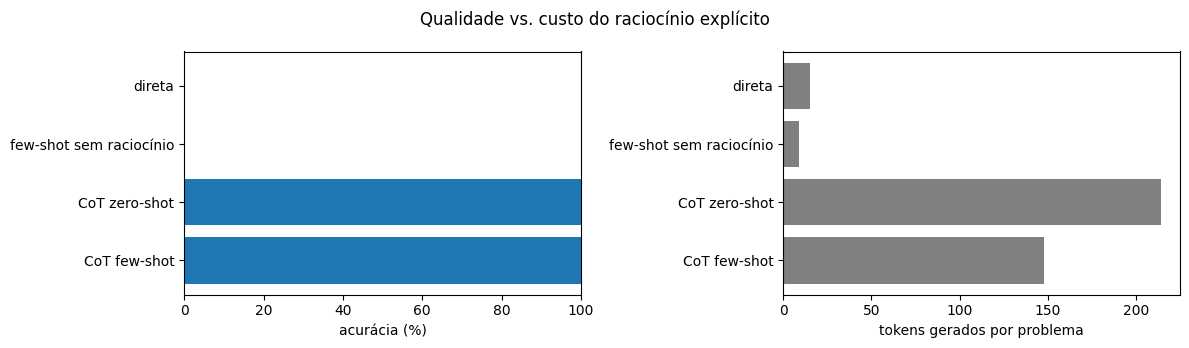

,problema,esperado,direta,few-shot sem raciocínio,CoT zero-shot,CoT few-shot
0,Uma loja vende canetas a R$ 3 cada ou em pacotes com 5 canet...,57,False,False,True,True
1,"Ana tem o triplo da idade de Bruno. Daqui a 6 anos, a soma d...",21,False,False,True,True
2,João lê 18 páginas por dia de segunda a sexta e 30 páginas p...,10,False,False,True,True
3,Três amigos dividiram uma conta de R$ 126. Carla pagou o dob...,60,False,False,True,True
4,Uma biblioteca tinha 148 livros. Recebeu 3 caixas com 24 liv...,163,False,False,True,True
5,Um ônibus sai do terminal com 41 passageiros. Na primeira pa...,24,False,False,True,True
6,Uma turma tem 36 alunos. Um quarto da turma faltou na segund...,18,False,False,True,True
7,Um tanque de 500 litros tem 50 litros de água. Uma torneira ...,30,False,False,True,True
8,Pedro comprou 3 camisas de R$ 40 e 2 calças de R$ 80 e ganho...,252,False,False,True,True
9,Uma sala tem 5 filas com 8 carteiras cada. Sete carteiras es...,36,False,False,True,True


In [82]:
resumos_raciocinio, detalhes_raciocinio = [], {}
for nome, (construtor, limite) in CONDICOES_RACIOCINIO.items():
    resumo, detalhe = avaliar_raciocinio(nome, construtor, problemas_avaliados, max_new_tokens=limite)
    resumos_raciocinio.append(resumo)
    detalhes_raciocinio[nome] = detalhe

tabela_raciocinio = pd.DataFrame(resumos_raciocinio)
display(tabela_raciocinio)

fig, eixos = plt.subplots(1, 2, figsize=(12, 3.5))
eixos[0].barh(tabela_raciocinio["configuração"], tabela_raciocinio["acurácia (%)"])
eixos[0].set_xlabel("acurácia (%)")
eixos[0].set_xlim(0, 100)
eixos[1].barh(tabela_raciocinio["configuração"], tabela_raciocinio["tokens médios"], color="gray")
eixos[1].set_xlabel("tokens gerados por problema")
for eixo in eixos:
    eixo.invert_yaxis()
plt.suptitle("Qualidade vs. custo do raciocínio explícito")
plt.tight_layout()
plt.show()

# Acerto por problema em cada condição
acertos = pd.DataFrame({nome: d["acerto"] for nome, d in detalhes_raciocinio.items()})
acertos.insert(0, "esperado", detalhes_raciocinio["direta"]["esperado"])
acertos.insert(0, "problema", detalhes_raciocinio["direta"]["enunciado"])
display(acertos)

In [83]:
# Veja um raciocínio completo (troque os índices para explorar erros)
condicao, indice = "CoT zero-shot", 0
print(detalhes_raciocinio[condicao].loc[indice, "resposta"])
print("\nNa condição direta, o modelo respondeu:", detalhes_raciocinio["direta"].loc[indice, "resposta"])

Para encontrar o menor valor para comprar exatamente 23 canetas, precisamos considerar as duas opções de compra:

1. Comprar canetas individuais a R$ 3 cada.
2. Comprar pacotes de 5 canetas por R$ 12 cada.

Primeiro, vamos calcular o custo de comprar 23 canetas individuais:

23 canetas * R$ 3/caneta = R$ 69

Agora, vamos calcular o custo de comprar pacotes de 5 canetas:

Como 23 canetas não podem ser compradas exatamente em pacotes de 5, precisamos comprar 4 pacotes de 5 canetas e 3 canetas individuais.

4 pacotes * R$ 12/pacote = R$ 48
3 canetas individuais * R$ 3/caneta = R$ 9

Agora, vamos somar o custo dos pacotes e das canetas individuais:

R$ 48 + R$ 9 = R$ 57

Comparando os dois valores, R$ 69 (canetas individuais) e R$ 57 (pacotes e canetas individuais), o menor valor para comprar exatamente 23 canetas é R$ 57.

Resposta: 57

Na condição direta, o modelo respondeu: Para encontrar o menor valor para comprar 23 canetas


**Como interpretar.** O CoT troca **tokens por acurácia**. Em uma API paga, esse custo aparece na fatura; em um modelo local, aparece no tempo. Note também que "responder apenas com o número" pode ser desobedecido: se o modelo começa a raciocinar e é cortado pelo limite de 15 tokens, o número extraído é um valor intermediário.

Dois fatos da literatura para discutir: Wei et al. (2022) observaram ganhos do CoT principalmente em modelos muito grandes, com modelos pequenos gerando cadeias ilógicas; modelos pequenos atuais, treinados com dados de raciocínio, mudaram esse cenário. Os modelos de raciocínio (*reasoning models*) levam a ideia ao extremo: geram o CoT internamente, antes da resposta visível.

**Pergunta para discussão.** Se a condição direta errou um problema e o CoT acertou, onde exatamente o raciocínio fez diferença? Olhe a resposta completa.

## Autoconsistência: amostrando várias saídas

Com temperatura mais alta, o mesmo prompt gera raciocínios diferentes a cada execução, e a qualidade varia por acaso. A autoconsistência (*self-consistency*; WANG et al., 2023) transforma essa variabilidade em vantagem: geramos $k$ raciocínios e escolhemos a resposta final por **votação majoritária** (ALAMMAR; GROOTENDORST, 2024, p. 188-189). O livro não traz código para esta seção.

### Comparação 13: uma resposta gulosa vs. votação entre $k$ amostras

**O que esperar.** A **acurácia média de uma amostra isolada** tende a ser menor que a da decodificação gulosa (a temperatura adiciona ruído), mas a **votação** entre as amostras tende a recuperar e às vezes superar a gulosa. O custo é aproximadamente $k$ vezes maior. Se o modelo já acertou tudo na Comparação 12, não há margem para melhora: use o Qwen 0.5B ou problemas mais difíceis.

In [ ]:
K_AMOSTRAS = 3 if MODO_RAPIDO else 5
detalhe_gulosa = detalhes_raciocinio["CoT zero-shot"]  # reaproveita a Comparação 12

linhas = []
for i, (enunciado, esperado) in enumerate(problemas_avaliados):
    set_seed(i)
    varias = gerar_varias(prompt_cot_zero(enunciado), K_AMOSTRAS, max_new_tokens=350,
                          do_sample=True, temperature=0.7, top_p=0.95)
    valores = [extrair_numero(t) for t in varias["textos"]]
    validos = [v for v in valores if v is not None]
    voto = Counter(validos).most_common(1)[0][0] if validos else None
    linhas.append({"problema": enunciado[:45] + "...", "esperado": esperado,
                   "gulosa": acertou(detalhe_gulosa.loc[i, "extraído"], esperado),
                   "acerto médio de uma amostra": np.mean([acertou(v, esperado) for v in valores]),
                   "voto": voto, "voto correto": acertou(voto, esperado),
                   "distribuição dos votos": dict(Counter(validos)),
                   "tokens gulosa": detalhe_gulosa.loc[i, "tokens"], "tokens amostras": varias["tokens"]})

resultado_sc = pd.DataFrame(linhas)
display(resultado_sc)
display(pd.DataFrame([{
    "acurácia gulosa (%)": round(100 * resultado_sc["gulosa"].mean(), 1),
    "acurácia média de 1 amostra (%)": round(100 * resultado_sc["acerto médio de uma amostra"].mean(), 1),
    f"acurácia do voto com k={K_AMOSTRAS} (%)": round(100 * resultado_sc["voto correto"].mean(), 1),
    "custo relativo (tokens)": round(resultado_sc["tokens amostras"].sum() / max(1, resultado_sc["tokens gulosa"].sum()), 1),
}]))

**Como interpretar.** A coluna "distribuição dos votos" mostra a **confiança** do conjunto: quando as amostras concordam, o voto é mais confiável; quando se dividem, o problema é difícil para o modelo. Essa concordância pode ser usada como sinal para acionar um humano ou uma ferramenta (por exemplo, uma calculadora), ideia que reaparece em agentes.

**Pergunta para discussão.** Com um limite de 1.000 requisições por dia em uma API gratuita, vale a pena usar $k=5$ em todas as perguntas? Em quais você usaria?

## Tree-of-Thought: explorando passos intermediários

O *Tree-of-Thought* explora vários caminhos de raciocínio em forma de árvore: a cada etapa, os pensamentos são avaliados, os ruins são descartados e os promissores são expandidos. A versão completa exige **muitas chamadas** ao modelo. A célula original usa uma versão simplificada, em **um único prompt**, que pede ao modelo para simular uma discussão entre três especialistas (HULBERT, 2023; ALAMMAR; GROOTENDORST, 2024, p. 189-191).

In [ ]:
# Zero-shot Chain-of-Thought
zeroshot_tot_prompt = [
    {"role": "user", "content": "Imagine three different experts are answering this question. All experts will write down 1 step of their thinking, then share it with the group. Then all experts will go on to the next step, etc. If any expert realises they're wrong at any point then they leave. The question is 'The cafeteria had 23 apples. If they used 20 to make lunch and bought 6 more, how many apples do they have?' Make sure to discuss the results."}
]


A saída de referência simula três especialistas (*Expert 1, 2 e 3*) que registram, passo a passo, 23 - 20 = 3 e 3 + 6 = 9, e depois revisam os cálculos até concordar que a cantina tem 9 maçãs.

In [ ]:
# Generate the output
outputs = pipe(zeroshot_tot_prompt)
print(outputs[0]["generated_text"])

### Comparação 14: CoT zero-shot vs. ToT em um único prompt

**O que esperar.** O prompt de ToT produz respostas bem mais longas (três "especialistas"). Ele pode ajudar em problemas nos quais um primeiro caminho de raciocínio costuma estar errado, mas também pode confundir modelos pequenos, que às vezes não chegam a um consenso. Comparamos com o CoT zero-shot da Comparação 12 nos mesmos problemas.

In [ ]:
def prompt_tot(enunciado):
    return usuario(
        "Imagine que três especialistas diferentes estão respondendo a esta pergunta. Cada especialista escreve "
        "1 passo do seu raciocínio e compartilha com o grupo. Depois, todos passam para o passo seguinte, e assim "
        "por diante. Se algum especialista perceber que errou em algum momento, ele sai da discussão. "
        f"A pergunta é: '{enunciado}' Discutam os resultados e, ao final, escrevam a resposta de consenso na "
        "forma 'Resposta: <número>'."
    )


problemas_tot = problemas_avaliados[:5]
resumo_tot, detalhe_tot = avaliar_raciocinio("ToT (um prompt)", prompt_tot, problemas_tot, max_new_tokens=600)

detalhe_cot = detalhes_raciocinio["CoT zero-shot"].iloc[:len(problemas_tot)]
resumo_cot = {"configuração": "CoT zero-shot",
              "acurácia (%)": round(100 * detalhe_cot["acerto"].mean(), 1),
              "tokens médios": round(detalhe_cot["tokens"].mean(), 1),
              "tempo total (s)": round(detalhe_cot["segundos"].sum(), 1)}
display(pd.DataFrame([resumo_cot, resumo_tot]))
print(detalhe_tot.loc[0, "resposta"][:2000])

**Como interpretar.** Em problemas aritméticos simples, o ToT de um único prompt raramente compensa o custo; ele foi pensado para problemas com **muitos caminhos possíveis** (planejamento, quebra-cabeças, escrita criativa). Lembre que este prompt é uma **emulação**: o modelo apenas escreve um texto que parece uma discussão, sem avaliação real nem busca. O ToT original (YAO et al., 2023) usa várias chamadas, uma função de avaliação e um algoritmo de busca (em largura ou em profundidade), o que já é, na prática, um fluxo agêntico.

**Pergunta para discussão.** Como você implementaria o ToT "de verdade" com as funções `gerar` e `gerar_varias` deste notebook? Quais seriam os nós da árvore e quem daria as notas?

# **Verificação da Saída**

Em sistemas reais, e especialmente em agentes, a saída do LLM é consumida por **código**. Precisamos garantir que ela venha em um formato válido (ALAMMAR; GROOTENDORST, 2024, p. 191-192).

## Fornecendo exemplos

A primeira célula pede um personagem de RPG em JSON **sem** mostrar a estrutura; a segunda fornece um **modelo** da estrutura desejada (ALAMMAR; GROOTENDORST, 2024, p. 192-194).

In [ ]:
# Zero-shot learning: Providing no examples
zeroshot_prompt = [
    {"role": "user", "content": "Create a character profile for an RPG game in JSON format."}
]

# Generate the output
outputs = pipe(zeroshot_prompt)
print(outputs[0]["generated_text"])

In [ ]:
# One-shot learning: Providing an example of the output structure
one_shot_template = """Create a short character profile for an RPG game. Make sure to only use this format:

{
  "description": "A SHORT DESCRIPTION",
  "name": "THE CHARACTER'S NAME",
  "armor": "ONE PIECE OF ARMOR",
  "weapon": "ONE OR MORE WEAPONS"
}
"""
one_shot_prompt = [
    {"role": "user", "content": one_shot_template}
]

# Generate the output
outputs = pipe(one_shot_prompt)
print(outputs[0]["generated_text"])

### Comparação 15: JSON sem exemplo vs. com exemplo da estrutura

Uma resposta isolada não diz muito: geramos várias amostras (temperatura 0,7) de cada prompt e medimos três níveis de exigência:

1. **`json.loads` direto**: a resposta inteira é JSON válido, sem nenhum tratamento;
2. **JSON após limpeza**: é possível recuperar um JSON removendo cercas de código (```` ```json ````) e texto ao redor;
3. **segue o esquema**: o objeto tem exatamente as chaves `description`, `name`, `armor` e `weapon`, todas com texto.

**O que esperar.** Sem exemplo, o modelo costuma envolver o JSON em cercas de Markdown (falha no nível 1) e inventa as próprias chaves (falha no nível 3). Com o exemplo, o esquema deve ser seguido na maioria das vezes, mas nada garante 100%.

In [ ]:
N_JSON = 3 if MODO_RAPIDO else 5
set_seed(0)
amostras_zero = gerar_varias(zeroshot_prompt, N_JSON, max_new_tokens=400, do_sample=True, temperature=0.7)
set_seed(0)
amostras_one = gerar_varias(one_shot_prompt, N_JSON, max_new_tokens=400, do_sample=True, temperature=0.7)

resumos_json = [
    resumir_json("zero-shot (sem estrutura)", amostras_zero["textos"], amostras_zero["tokens"] / N_JSON),
    resumir_json("one-shot (com estrutura)", amostras_one["textos"], amostras_one["tokens"] / N_JSON),
]
display(pd.DataFrame(resumos_json))

print("Exemplo zero-shot (início):\n", amostras_zero["textos"][0][:400])
print("\nChaves encontradas nas amostras zero-shot:",
      [sorted(extrair_json(t)) if isinstance(extrair_json(t), dict) else None for t in amostras_zero["textos"]])

**Como interpretar.** "Quase sempre" não é suficiente para um programa: se 1 em cada 20 respostas quebrar o `json.loads`, o agente quebra 1 em cada 20 vezes. A próxima seção mostra como **garantir** o formato.

# **Bônus: repetindo comparações com a API gratuita do Gemini**

Até aqui usamos modelos pequenos, rodando localmente. Vamos repetir duas comparações com um modelo muito maior, acessado pela API do Gemini no nível gratuito do Google AI Studio, **sem cartão de crédito**.

**Preparação (uma única vez):**

1. Acesse o Google AI Studio (https://aistudio.google.com), entre com uma conta Google e crie uma chave de API.
2. No Colab, clique no ícone de chave (Secrets), crie o segredo `GEMINI_API_KEY` com o valor da chave e habilite o acesso ao notebook. Em uma instância EC2, use a variável de ambiente `GEMINI_API_KEY`.
3. **Nunca** escreva a chave diretamente no código, nem a envie para o GitHub.

**Cuidados:**

* Os limites do nível gratuito (requisições por minuto e por dia) variam por modelo e mudam com frequência; confira os valores atuais no AI Studio. Por isso as células abaixo fazem uma pausa entre chamadas e usam poucos problemas.
* Segundo os termos do Gemini API, os dados enviados no nível gratuito podem ser usados pelo Google para melhorar seus produtos. **Não envie dados pessoais de alunos ou servidores** (LGPD).
* Esta seção depende apenas das funções da célula de utilitários e das definições da Comparação 12 (lista `problemas` e funções `prompt_*`). Se você reiniciou o ambiente, execute essas células de novo; não é preciso carregar o modelo local.

In [ ]:
# !pip install -q google-genai
import os
from google import genai
from google.genai import types


def obter_chave_gemini():
    try:
        from google.colab import userdata
        chave = userdata.get("GOOGLE_API_KEY")
        if chave:
            return chave
    except Exception:
        pass
    if os.environ.get("GOOGLE_API_KEY"):
        return os.environ["GOOGLE_API_KEY"]
    from getpass import getpass
    return getpass("Cole sua chave do Google AI Studio: ")


cliente = genai.Client(api_key=obter_chave_gemini())

# Lista os modelos disponíveis para a sua chave e escolhe automaticamente um modelo "flash-lite"
disponiveis = sorted(
    m.name.removeprefix("models/") for m in cliente.models.list()
    if "generateContent" in (getattr(m, "supported_actions", None) or [])
)
print("Modelos com generateContent:\n ", "\n  ".join(disponiveis))

leves = [n for n in disponiveis if "flash-lite" in n and "preview" not in n]
MODELO_GEMINI = leves[-1] if leves else "gemini-2.5-flash-lite"  # troque manualmente se preferir outro
print("\nModelo escolhido:", MODELO_GEMINI)

A função abaixo tem a **mesma interface** de `gerar`: recebe uma string ou uma lista de mensagens e devolve texto, tokens e tempo. Com isso, as funções de avaliação do notebook funcionam sem mudança, bastando passar `gerador=gerar_gemini`.

Dois detalhes importantes:

* No Gemini, o papel do assistente se chama `model`, e não `assistant`; a função faz a conversão.
* Muitos modelos Gemini recentes **"pensam" antes de responder** (*thinking*), e esses tokens de raciocínio também contam no limite de saída e na cobrança. Por isso o limite mínimo é de 1.024 tokens, e a coluna `tokens` soma os tokens da resposta e os de raciocínio.
* A função **não** força temperatura 0 quando `do_sample=False`: ela mantém a configuração padrão do modelo. O guia do Gemini 3 recomenda manter a temperatura no valor padrão (1,0), pois valores menores podem causar repetições em laço ou pior desempenho em tarefas de raciocínio. Ou seja, a recomendação "temperatura baixa para tarefas determinísticas" dos slides é uma heurística que **depende do modelo**. Consequência: nas APIs, as respostas não são exatamente reproduzíveis.

In [ ]:
PAUSA_ENTRE_CHAMADAS = 6  # segundos; evita estourar o limite de requisições por minuto


def gerar_gemini(entrada, max_new_tokens=512, do_sample=False, temperature=None, top_p=None, top_k=None, **ignorados):
    mensagens = usuario(entrada) if isinstance(entrada, str) else entrada
    conteudos = [types.Content(role="model" if m["role"] == "assistant" else "user",
                               parts=[types.Part.from_text(text=m["content"])])
                 for m in mensagens if m["role"] != "system"]
    config = {"max_output_tokens": max(max_new_tokens, 1024)}
    if do_sample:  # só altera a amostragem se pedido explicitamente; caso contrário, usa o padrão do modelo
        config.update({k: v for k, v in {"temperature": temperature, "top_p": top_p, "top_k": top_k}.items() if v})
    inicio = time.perf_counter()
    try:
        resposta = cliente.models.generate_content(model=MODELO_GEMINI, contents=conteudos,
                                                   config=types.GenerateContentConfig(**config))
        texto = resposta.text or ""
        uso = resposta.usage_metadata
        tokens = (getattr(uso, "candidates_token_count", 0) or 0) + (getattr(uso, "thoughts_token_count", 0) or 0)
    except Exception as erro:  # por exemplo, erro 429 (limite de requisições)
        texto, tokens = f"[ERRO: {erro}]", 0
    duracao = time.perf_counter() - inicio
    time.sleep(PAUSA_ENTRE_CHAMADAS)
    return {"texto": texto.strip(), "tokens": tokens, "segundos": round(duracao, 2)}


mostrar("Teste do Gemini", gerar_gemini("Responda em uma frase: o que é um token em um LLM?"))

### Bônus 1: resposta direta vs. CoT no Gemini

**O que esperar.** Um modelo grande, e que talvez raciocine internamente, deve acertar mesmo na condição direta. Se isso acontecer, observe a coluna de tokens: o "raciocínio" continua existindo, só que escondido. O próprio guia do Gemini 3 sugere trocar prompts de CoT elaborados por um nível de raciocínio interno maior (parâmetro `thinking_level`): o raciocínio migrou do prompt para o modelo.

In [ ]:
problemas_gemini = problemas[:4]  # poucos problemas para respeitar a cota gratuita
resumos_gemini = []
for nome in ["direta", "CoT zero-shot"]:
    construtor, limite = CONDICOES_RACIOCINIO[nome]
    resumo, _ = avaliar_raciocinio(f"Gemini: {nome}", construtor, problemas_gemini,
                                   gerador=gerar_gemini, max_new_tokens=limite)
    resumos_gemini.append(resumo)
display(pd.DataFrame(resumos_gemini))

### Bônus 2: saída estruturada com esquema no Gemini

A API do Gemini aceita um esquema (aqui, uma classe Pydantic) e aplica a restrição do lado do servidor, como a gramática do llama.cpp. O pedido é o mesmo da Comparação 16 (em inglês, com as chaves do exemplo original).

In [ ]:
from pydantic import BaseModel


class PerfilPersonagem(BaseModel):
    description: str
    name: str
    armor: str
    weapon: str


pedido = ("Create a short character profile for an RPG game in JSON format "
          "with the fields description, name, armor and weapon.")
N_GEMINI_JSON = 3

sem_esquema, com_esquema = [], []
for _ in range(N_GEMINI_JSON):
    sem_esquema.append(gerar_gemini(pedido, max_new_tokens=400)["texto"])
    try:
        resposta = cliente.models.generate_content(
            model=MODELO_GEMINI, contents=pedido,
            config=types.GenerateContentConfig(response_mime_type="application/json",
                                               response_schema=PerfilPersonagem),
        )
        com_esquema.append(resposta.text or "")
    except Exception as erro:
        com_esquema.append(f"[ERRO: {erro}]")
    time.sleep(PAUSA_ENTRE_CHAMADAS)

display(pd.DataFrame([resumir_json("Gemini sem esquema", sem_esquema),
                      resumir_json("Gemini com esquema", com_esquema)]))
print(com_esquema[0])

**Pergunta para discussão.** Quais técnicas deste notebook fizeram mais diferença no modelo pequeno do que no Gemini? O que isso sugere para a escolha do modelo no projeto final, considerando custo, cota gratuita e privacidade dos dados?

# **Síntese**

| Técnica | Quando ajuda | Custo | Onde reaparece no curso |
|---|---|---|---|
| *Chat template* | Sempre que se usa um modelo de chat fora de uma interface pronta | Nenhum | Frameworks de agentes montam as mensagens por você |
| Temperatura, top_p, top_k | Ajustar diversidade vs. previsibilidade | Nenhum | Agentes usam valores baixos para decisões e chamadas de ferramentas |
| Instrução, indicadores de saída, formato | Saídas consumidas por código | Poucos tokens | Roteamento e *parsing* em agentes |
| Especificidade | Quase sempre | Poucos tokens | Descrições de ferramentas e de agentes |
| "Se não souber, diga Não sei" | Perguntas factuais sem fonte | Pode gerar abstenções indevidas | RAG e *guardrails* |
| Ordem (início ou fim) | Prompts longos | Nenhum | Contextos com documentos e históricos longos |
| Few-shot | Formatos e tarefas específicos do seu sistema | Prompt maior em toda chamada | Prompts de sistema de agentes |
| Encadeamento | Tarefas com etapas verificáveis | Mais chamadas | Fluxos agênticos (*workflows*) |
| Chain-of-Thought | Problemas de várias etapas | Muito mais tokens de saída | Planejamento (ReAct) |
| Autoconsistência | Quando errar custa caro | Cerca de $k$ vezes mais | Sinal de confiança para acionar humanos ou ferramentas |
| Tree-of-Thought | Problemas com muitos caminhos | Alto | Busca e planejamento com múltiplos agentes |
| Exemplo de estrutura, gramática, esquema | Saídas estruturadas | Baixo; a gramática exige suporte da biblioteca ou da API | *Function calling*, MCP |

## Para explorar

1. Rode o notebook com o Phi-3 (GPU) e com o Qwen2.5-0.5B (CPU) e compare as tabelas das Comparações 4, 12 e 15. Em qual modelo as técnicas fazem mais diferença?
2. Na Comparação 7, aumente `REPETICOES_DOCUMENTO` até perto do limite da janela de contexto (o Qwen2.5 aceita contextos bem maiores que o Phi-3-mini-4k). O efeito "*lost in the middle*" aparece?
3. Na Comparação 10, inverta a ordem dos exemplos ou use apenas exemplos de urgência `alta`. A distribuição das respostas muda? (ver ZHAO et al., 2021)
4. Implemente um ToT com múltiplas chamadas: gere três primeiros passos com `gerar_varias`, peça ao modelo uma nota de 1 a 10 para cada um, expanda apenas o melhor e repita.
5. Repita a Comparação 10 (triagem) com o Gemini. Isso é, essencialmente, o roteador de um agente de atendimento.

# **Referências**

ABDIN, M. et al. Phi-3 technical report: a highly capable language model locally on your phone. *arXiv preprint* arXiv:2404.14219, 2024.

ALAMMAR, J.; GROOTENDORST, M. *Hands-On Large Language Models: Language Understanding and Generation*. Sebastopol: O'Reilly Media, 2024. Cap. 6: Prompt Engineering, p. 167-198. Código: https://github.com/HandsOnLLM/Hands-On-Large-Language-Models

BERRYMAN, J.; ZIEGLER, A. *Prompt Engineering for LLMs: The Art and Science of Building Large Language Model-Based Applications*. Sebastopol: O'Reilly Media, 2024.

BROWN, T. et al. Language models are few-shot learners. *Advances in Neural Information Processing Systems*, v. 33, p. 1877-1901, 2020.

